<div style="border: 3px solid #1f6fb2; border-radius: 10px; padding: 52px 44px; text-align: center; background: linear-gradient(160deg, #f8fbff 0%, #e4f0fc 100%); margin-bottom: 8px;">
  <div style="font-size: 56px; font-weight: 900; color: #1f6fb2; letter-spacing: 4px; margin-bottom: 18px; font-family: sans-serif;">
    ICU SEPSIS RL
  </div>
  <div style="font-size: 20px; font-weight: 700; color: #1a3a5c; margin-bottom: 8px;">
    Clinical Treatment Optimisation: Sepsis ICU Management
  </div>
  <div style="font-size: 15px; font-style: italic; color: #4a6a8a; margin-bottom: 38px;">
    Configuration B – Deep Reinforcement Learning
  </div>
  <hr style="border: none; border-top: 2px solid #1f6fb2; width: 48%; margin: 0 auto 28px auto;">
  <div style="font-size: 14px; font-weight: 600; color: #1a3a5c; margin-bottom: 6px;">
    Ana Gonçalves &nbsp;|&nbsp; Catarina &nbsp;|&nbsp; Filipa São João &nbsp;|&nbsp; Inês Esteves &nbsp;|&nbsp; Maria
  </div>
  <div style="font-size: 13px; font-style: italic; color: #6a8aaa;">
    NOVA IMS – Master in Data Science &amp; Advanced Analytics - Reinforcement Learning - May 2026
  </div>
</div>


<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Environment Exploration](#3)
  - [3.1 Observation Space - 47 Physiological Features](#3_1)
  - [3.2 Random Baseline - Base Environment](#3_2)
  - [3.3 Random Baseline - Clinical Environment (Wrappers)](#3_3)
  - [3.4 Environment Comparison (Base vs Clinical)](#3_4)
  - [3.5 Feature Outcome Relationship](#3_5)
  - [3.6 Action Space — Treatment Intensity](#3_6)

# <font color='#2f94d7' size=6>**1. Project Overview - Config B**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite.

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.


Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

# <font color='#2f94d7' size=6>**2. Set Up & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [ ]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys
import gymnasium as gym
import random
import time
import itertools

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
from collections import deque

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

warnings.filterwarnings('ignore')

# Project modules
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)
from envs.continuous_sepsis_env import ContinuousICUSepsisEnv, FEATURE_NAMES
from envs.wrappers import (
    EpisodicNoisyObsEnv, EpisodicMissingObsEnv,
    AcuteEventEnv, make_clinical_env
)

# Import everything from functions_config_B.py
from functions_config_B import *

# Config B constants
OBS_DIM = 47

# Create environment and model
#env   = make_clinical_env()
#model = A2CNetwork(obs_dim=OBS_DIM, n_actions=N_ACTIONS).to(device)
#opt   = torch.optim.Adam(model.parameters(), lr=lr)
# meti comentado porque não sei se não vamos precisar mais tarde mas não pode ficar aqui

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')

Device: cpu
ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


In [7]:
# Config B observation constants
OBS_DIM  = 47   # 47 physiological features

In [8]:
# Verify wrapper stack order
test_env = make_clinical_env()
e = test_env
layers = []
while hasattr(e, 'env'):
    layers.append(type(e).__name__)
    e = e.env
layers.append(type(e).__name__)
test_env.close()


print()
print('Clinical environment wrapper stack (outer → inner):')
for i, layer in enumerate(layers):
    prefix = '  ' * i + ('└─ ' if i > 0 else '┌─ ')
    print(f'{prefix}{layer}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Clinical environment wrapper stack (outer → inner):
┌─ AcuteEventEnv
  └─ EpisodicMissingObsEnv
    └─ EpisodicNoisyObsEnv
      └─ ContinuousICUSepsisEnv


In [9]:
# REPRODUCIBILITY
SEED      = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# <font color='#2f94d7' size=6>**3. Environment Exploration**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**3.1 Observation Space — 47 Physiological Features**</font> <a class="anchor" id="3_1"></a>

[Back to TOC](#toc)

The cluster centres of the 714 non-terminal states are extracted directly from the environment. Each row is a normalised physiological feature vector that the agent observes.

In [10]:
# Build the base continuous env and extract cluster centres
base_env = ContinuousICUSepsisEnv(params=make_sepsis_env())

# Shape: (716, 47).  Rows 714 and 715 are terminal states — drop them.
all_centers = base_env._cluster_centers          # (716, 47)
clinical_centers = all_centers[:714]             # (714, 47) — non-terminal only

df_states = pd.DataFrame(clinical_centers, columns=FEATURE_NAMES)

print()
print(f'Clinical state matrix shape : {clinical_centers.shape}')
print('Summary statistics (first 8 features):')
df_states.describe().T.head(8).round(3)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Clinical state matrix shape : (714, 47)
Summary statistics (first 8 features):


,count,mean,std,min,25%,50%,75%,max
Albumin,714.0,-0.061,0.125,-0.479,-0.148,-0.060,0.022,0.327
ALP,714.0,-0.134,0.289,-0.500,-0.373,-0.225,0.079,0.500
ALT,714.0,-0.425,0.213,-0.500,-0.496,-0.479,-0.434,3.722
AST,714.0,0.449,0.165,0.000,0.335,0.426,0.538,1.100
Bilirubin,714.0,-0.020,0.579,-2.166,-0.355,0.068,0.412,1.094
BUN,714.0,0.034,0.629,-0.825,-0.263,-0.068,0.140,5.403
Chloride,714.0,-0.055,0.746,-2.521,-0.224,0.256,0.436,0.672
Creatinine,714.0,0.064,0.695,-1.276,-0.495,-0.044,0.578,2.221


The base environment exposes a (714, 47) matrix of cluster centres,
one centroid per non-terminal clinical state, with 47 physiological
features each (the same variables used in Komorowski et al. 2018).

**Key observations:**
- All 714 states have complete feature vectors (no missing values in
  the state representation itself)
- Features are approximately centred at 0, confirming normalisation, so
  no additional preprocessing is needed before feeding observations to
  a neural network
- Some features show high maximum values (e.g. BUN, ALT), reflecting
  clusters of patients in critical condition, expected in an ICU setting

The 714 × 47 continuous state space makes tabular methods infeasible,
motivating the use of function approximation in Config B.

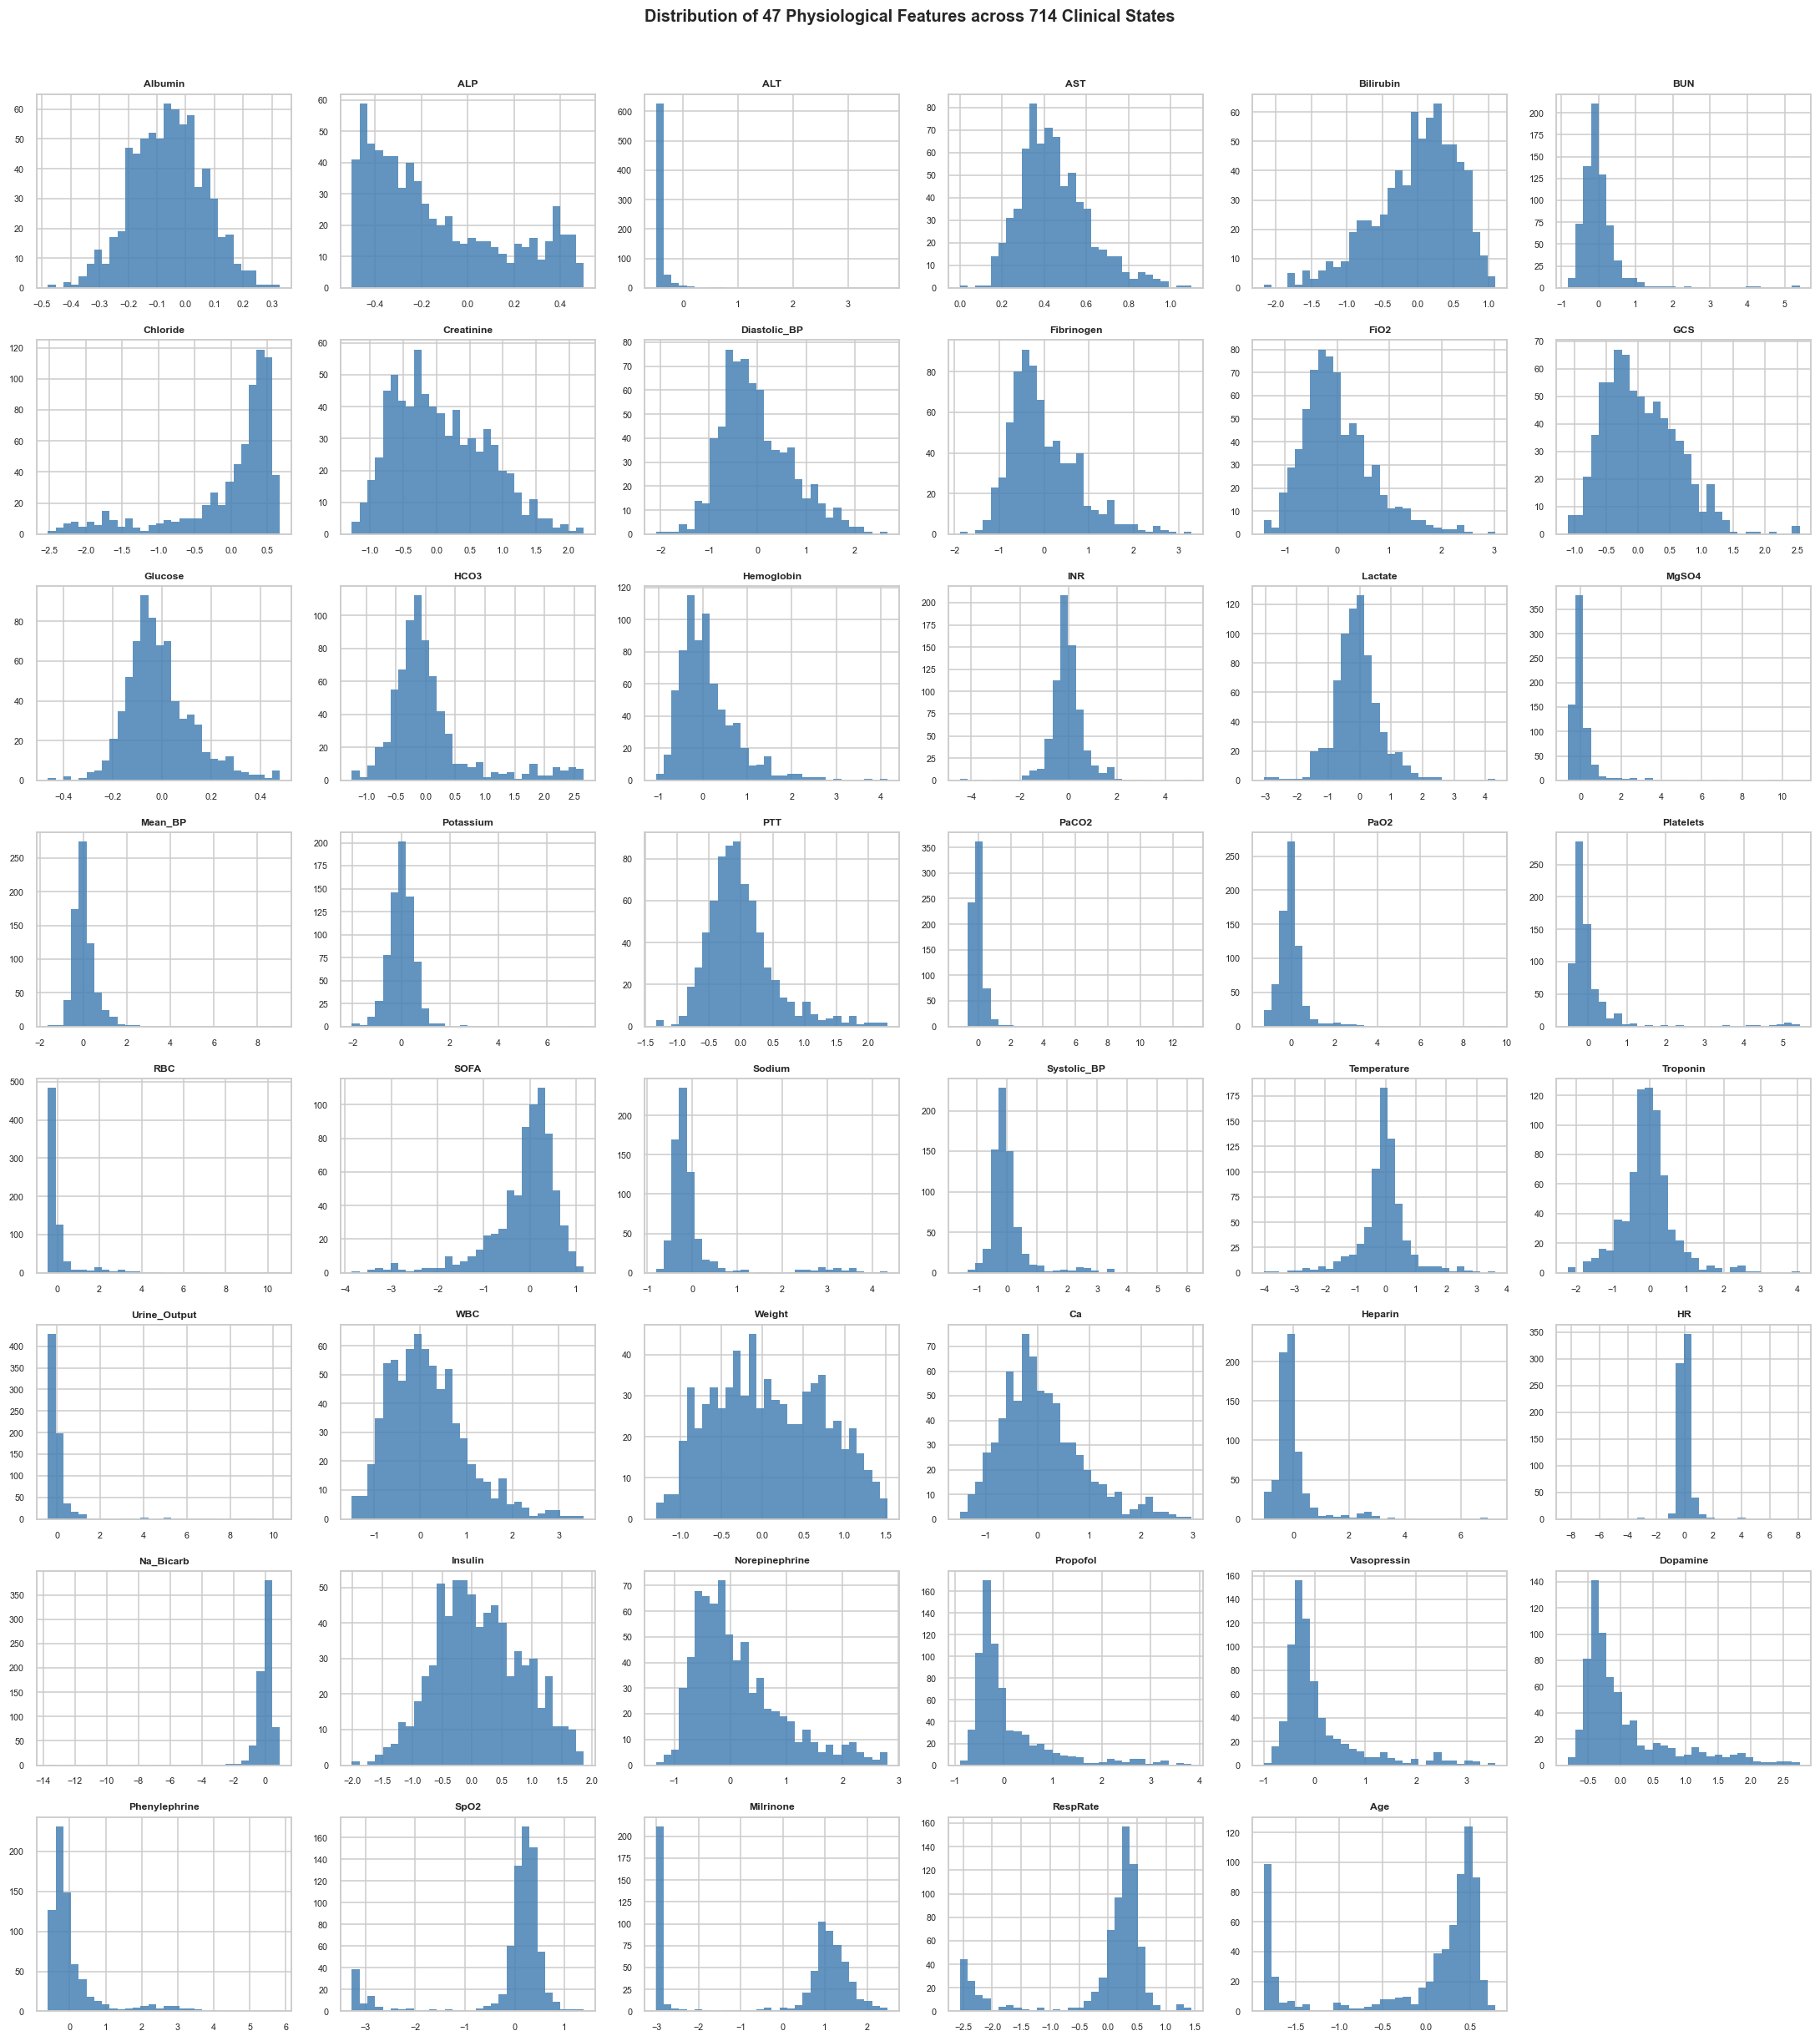

In [11]:
# Distribution of all 47 features across states
fig, axes = plt.subplots(8, 6, figsize=(20, 22))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    ax.hist(df_states[feat], bins=30, color='steelblue', edgecolor='none', alpha=0.85)
    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

# hide spare axes (47 features, 48 subplots)
for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of 47 Physiological Features across 714 Clinical States',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The 47 physiological features show a lot of right-skewed distributions typical
of ICU data, most patients cluster around normal values, with a minority
in critical states driving extreme observations. Several treatment-related
features (e.g. Milrinone, Vasopressin, Norepinephrine) are zero for most
states, reflecting that aggressive interventions are used selectively.

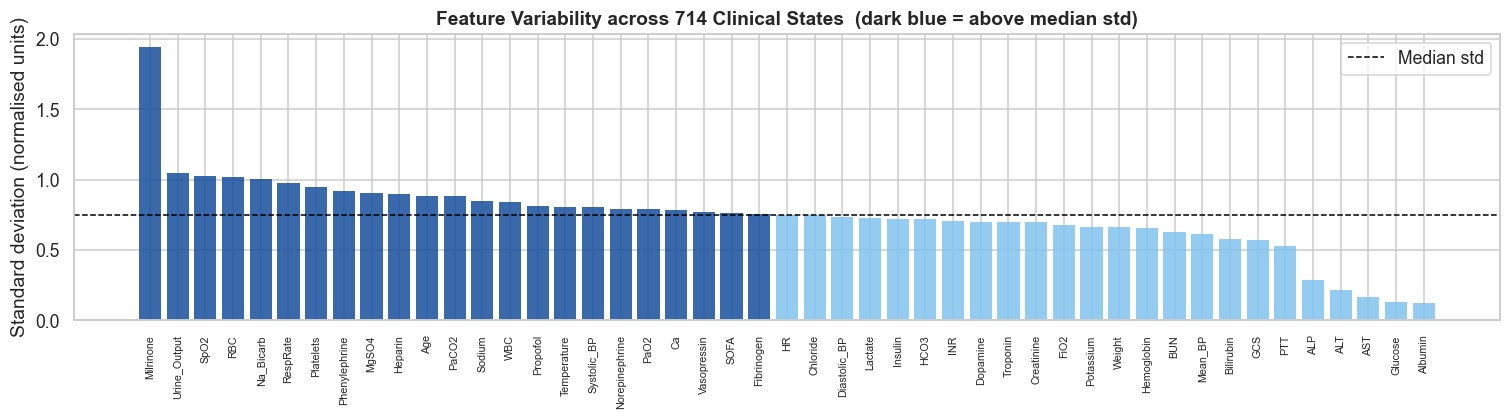

In [12]:
# Feature variance ranking
feat_std = df_states.std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#164f9b" if s > feat_std.median() else "#81c2ee" for s in feat_std]
ax.bar(feat_std.index, feat_std.values, color=colors, edgecolor='none', alpha=0.85)
ax.set_xticks(range(len(feat_std)))
ax.set_xticklabels(feat_std.index, rotation=90, fontsize=7)
ax.set_ylabel('Standard deviation (normalised units)')
ax.set_title('Feature Variability across 714 Clinical States  '
             '(dark blue = above median std)', fontweight='bold')
ax.axhline(feat_std.median(), color='black', ls='--', lw=1, label='Median std')
ax.legend()
plt.tight_layout()
plt.show()

Features vary substantially in how much they differ across the 714 clinical
states. High-variability features (e.g. Milrinone, Urine_Output, SpO2,
RBC) are more discriminative between states (red bars), while low-variability features
(e.g. Albumin, Glucose, AST) contribute less to distinguishing clinical
conditions (blue bars). This suggests the observation space contains redundancy,
not all 47 features carry equal information for the agent.

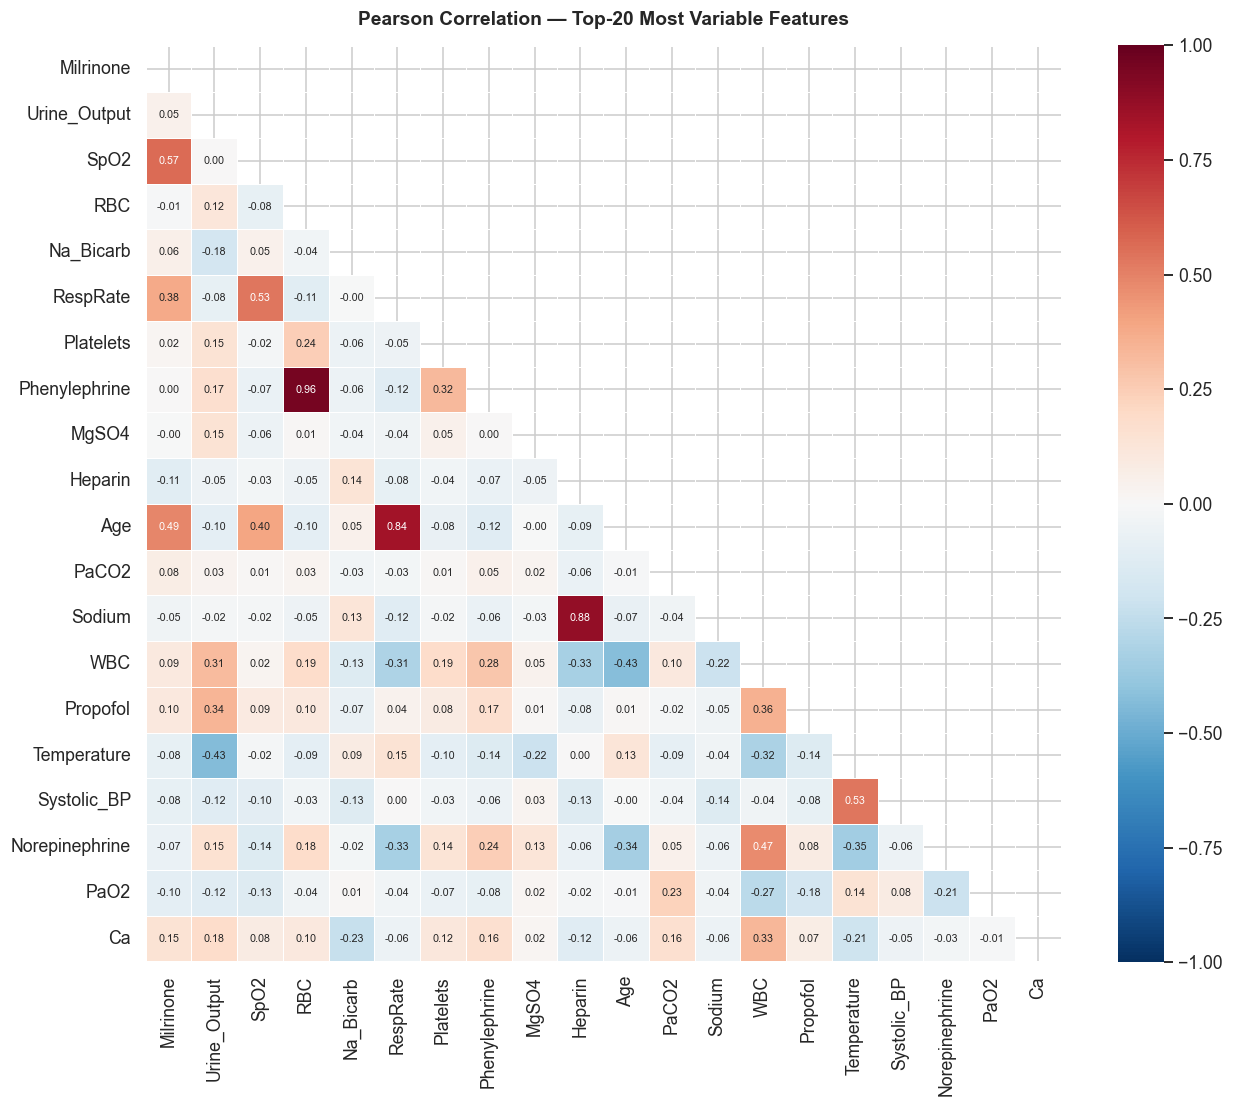

In [13]:
# Correlation heatmap (top-20 most variable features)
top20 = feat_std.head(20).index.tolist()
corr  = df_states[top20].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    square=True, linewidths=0.4, ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Pearson Correlation — Top-20 Most Variable Features',
             fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

Most feature pairs are weakly correlated, meaning the observation vector
carries largely complementary information. However, three pairs show
notably high correlation:
- **RBC - Phenylephrine (r=0.96)** — near-redundant features
- **Sodium - Heparin (r=0.88)** — strong association between
  electrolyte levels and anticoagulation treatment
- **Age - RespRate (r=0.84)** — older patients tend to present higher
  respiratory rates, reflecting reduced physiological reserve

These correlations are unlikely to cause problems for a neural network
but are worth noting as sources of redundancy in the input space.

## <font color='#2f94d7' size=6>**3.2 Random Baseline - Base Environment**</font> <a class="anchor" id="3_2"></a>

[Back to TOC](#toc)

We roll out `N_EPISODES = 1000` episodes using a uniformly random policy to characterise baseline episode length, survival rate, and reward distribution **before any learning**.


> **Note:** results vary slightly between runs as each episode is initialised
> with a different random seed. Values reported reflect typical observed ranges.

In [14]:
# Random-policy rollouts on the clean base env

N_EPISODES = 1000   # episodes for random-policy rollouts

print('Rolling out random policy on clean base env:')
records_clean = rollout(base_env, N_EPISODES)
df_ep = pd.DataFrame([{k: v for k, v in r.items() if k != 'obs_traj'}
                       for r in records_clean])

survival_rate = df_ep['survived'].mean()
mean_length   = df_ep['length'].mean()
print(f'Random policy  |  Survival rate: {survival_rate:.1%}  '
      f'|  Mean episode length: {mean_length:.1f} steps')

Rolling out random policy on clean base env:
Random policy  |  Survival rate: 72.3%  |  Mean episode length: 10.0 steps


With this results it's possible to understand that each episode simulates a sequence of ~10 treatment decisions (vasopressor + IV fluid dose). Any trained agent must exceed the survival rate recorded
here to demonstrate meaningful learning.

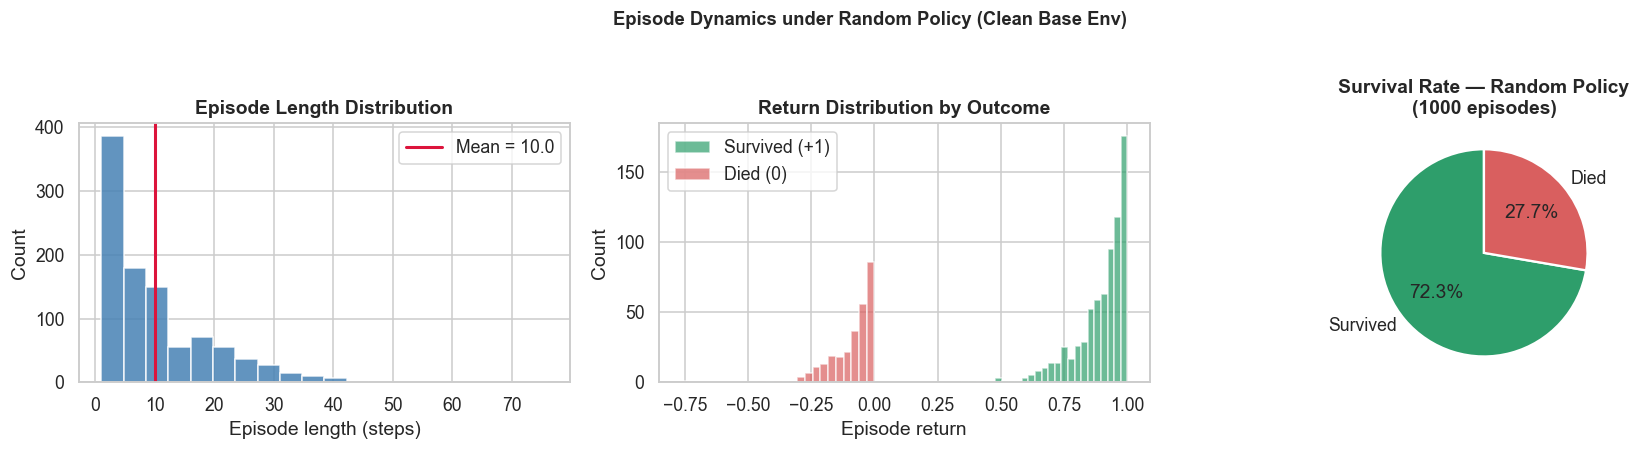

In [15]:
# Episode length & return distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Episode length
axes[0].hist(df_ep['length'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(mean_length, color='crimson', lw=2, label=f'Mean = {mean_length:.1f}')
axes[0].set_xlabel('Episode length (steps)')
axes[0].set_ylabel('Count')
axes[0].set_title('Episode Length Distribution', fontweight='bold')
axes[0].legend()

# Return distribution
survived_col = df_ep['survived'].map({True: 'Survived (+1)', False: 'Died (0)'})
for outcome, colour in [('Survived (+1)', '#2E9E6B'), ('Died (0)', '#D95F5F')]:
    mask = survived_col == outcome
    axes[1].hist(df_ep.loc[mask, 'return'], bins=25,
                 label=outcome, color=colour, alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Episode return')
axes[1].set_ylabel('Count')
axes[1].set_title('Return Distribution by Outcome', fontweight='bold')
axes[1].legend()

# Survival pie
counts = df_ep['survived'].value_counts()
axes[2].pie(
    [counts.get(True, 0), counts.get(False, 0)],
    labels=['Survived', 'Died'],
    colors=["#2E9E6B", "#D95F5F"],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[2].set_title(f'Survival Rate — Random Policy\n({N_EPISODES} episodes)',
                  fontweight='bold')

plt.suptitle('Episode Dynamics under Random Policy (Clean Base Env)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Episode length:** is right-skewed, most episodes resolve in fewer than 10
steps, though a long tail exists where patients take much longer to stabilise
or deteriorate. The mean episode length is ~10 steps.

**Return distribution by Outcome:** shows two clear clusters: episodes ending in death
concentrate near 0, while survival episodes cluster close to 1.0 but rarely
reach it exactly, the treatment intensity penalty (lam=0.02) accumulates
across steps and slightly reduces the final return even in survived episodes.

**Survival rate: ~72%** under a random policy on the clean environment.
This is the performance floor for the base environment — trained agents
must exceed this to demonstrate meaningful learning.

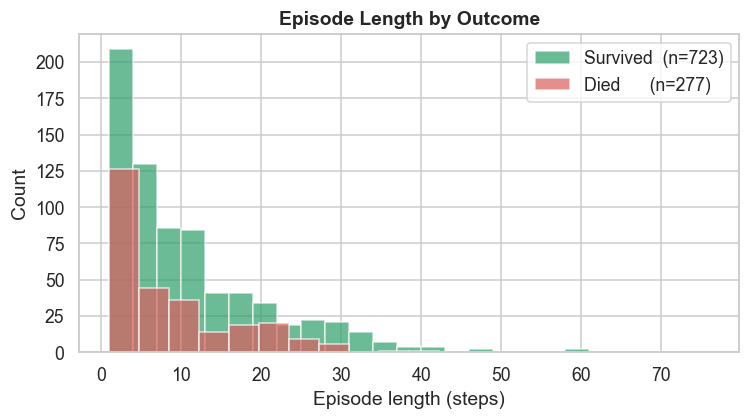

Survived — mean length: 10.47  std: 9.97
Died     — mean length: 8.91  std: 8.86


In [16]:
# Episode length by outcome
fig, ax = plt.subplots(figsize=(7, 4))
survived_lengths = df_ep.loc[df_ep['survived'],  'length']
died_lengths     = df_ep.loc[~df_ep['survived'], 'length']

ax.hist(survived_lengths, bins=20, alpha=0.7, color="#2E9E6B",
        label=f'Survived  (n={len(survived_lengths)})', edgecolor='white')
ax.hist(died_lengths,     bins=20, alpha=0.7, color="#D95F5F",
        label=f'Died      (n={len(died_lengths)})',     edgecolor='white')
ax.set_xlabel('Episode length (steps)')
ax.set_ylabel('Count')
ax.set_title('Episode Length by Outcome', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Survived — mean length: {survived_lengths.mean():.2f}  '
      f'std: {survived_lengths.std():.2f}')
print(f'Died     — mean length: {died_lengths.mean():.2f}  '
      f'std: {died_lengths.std():.2f}')

Survived and died episodes show nearly identical length distributions
(survived: mean ~10.5 steps, died: mean ~9.9 steps), with high variability
in both groups (std ~ 10).

This confirms that under a random policy, episode length is not predictive
of outcome, a patient can die quickly or after many steps regardless of
how many treatment decisions were made. What matters is the **quality** of
those decisions, not the quantity.

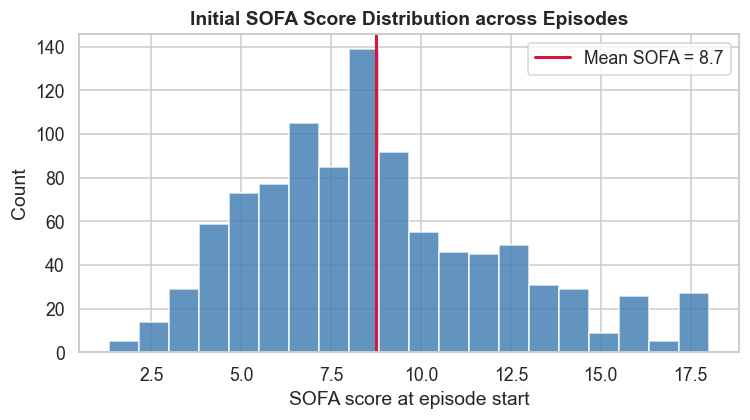

Mean SOFA : 8.75
Std SOFA  : 3.49
Min SOFA  : 1
Max SOFA  : 18


In [17]:
# SOFA score distribution at episode start
sofa_scores = []
rng_sofa = np.random.default_rng(SEED)
for i in range(N_EPISODES):
    _, info = base_env.reset(seed=int(rng_sofa.integers(1_000_000)))
    sofa_scores.append(info['sofa_score'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sofa_scores, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(sofa_scores), color='crimson', lw=2,
           label=f'Mean SOFA = {np.mean(sofa_scores):.1f}')
ax.set_xlabel('SOFA score at episode start')
ax.set_ylabel('Count')
ax.set_title('Initial SOFA Score Distribution across Episodes', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean SOFA : {np.mean(sofa_scores):.2f}')
print(f'Std SOFA  : {np.std(sofa_scores):.2f}')
print(f'Min SOFA  : {np.min(sofa_scores):.0f}')
print(f'Max SOFA  : {np.max(sofa_scores):.0f}')

The SOFA (Sequential Organ Failure Assessment) score measures organ failure
severity at the start of each episode. Higher values indicate more critical
patients and in clinical practice, scores above 8 are associated with high
mortality risk.

**Key statistics:** mean 8.75, std 3.49, range [1, 18]

The distribution is approximately bell-shaped, with most episodes starting
between SOFA 5 and 12. This reflects the `sofa_bias=5.0` parameter in the
environment, which deliberately skews the patient population towards more
severe cases.

This confirms that the agent always starts from a difficult
clinical situation, it is never treating mild cases, which justifies the
complexity of the learning problem ahead.

## <font color='#2f94d7' size=6>**3.3 Random Baseline - Clinical Environment (Wrappers Env)**</font> <a class="anchor" id="3_3"></a>

[Back to TOC](#toc)

> **Note:** results vary slightly between runs due to two sources of
> stochasticity: random episode seeds (as in section 3.2) and the
> probabilistic clinical wrappers (noisy observations at 15% of episodes,
> missing features at 15% of episodes). Values reported reflect typical
> observed ranges.

In [18]:
# Reuse rollout() on the clinical environment (with wrappers)
clinical_env = make_clinical_env()
records_clinical = rollout(clinical_env, N_EPISODES)
clinical_env.close()

print()

df_clinical = pd.DataFrame([{k: v for k, v in r.items() if k != 'obs_traj'}
                             for r in records_clinical])

clinical_rand_mean = df_clinical['return'].mean()
survival_clinical  = df_clinical['survived'].mean() * 100

noisy_mask   = df_clinical['noisy_episode'] == True
missing_mask = df_clinical['missing_features'].notna()

print(f'Random Baseline: Clinical Environment ({N_EPISODES} episodes):')
print(f'  Overall mean reward return : {clinical_rand_mean:.4f}')
print(f'  Overall survival rate      : {survival_clinical:.1f}%')
print()
print(f'Breakdown by wrapper condition:')
print(f'  Noisy episodes        : {noisy_mask.sum():>4}  | mean reward return: {df_clinical.loc[noisy_mask, "return"].mean():.4f}')
print(f'  Clean episodes        : {(~noisy_mask).sum():>4}  | mean reward return: {df_clinical.loc[~noisy_mask, "return"].mean():.4f}')
print(f'  Missing obs episodes  : {missing_mask.sum():>4}  | mean reward return: {df_clinical.loc[missing_mask, "return"].mean():.4f}')
print(f'  Complete obs episodes : {(~missing_mask).sum():>4}  | mean reward return: {df_clinical.loc[~missing_mask, "return"].mean():.4f}')
print()
print(f'  >> Trained agents must exceed survival rate > {survival_clinical:.1f}% and mean reward return > {clinical_rand_mean:.4f}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Random Baseline: Clinical Environment (1000 episodes):
  Overall mean reward return : 0.5607
  Overall survival rate      : 65.1%

Breakdown by wrapper condition:
  Noisy episodes        :  162  | mean reward return: 0.5345
  Clean episodes        :  838  | mean reward return: 0.5657
  Missing obs episodes  :  167  | mean reward return: 0.5801
  Complete obs episodes :  833  | mean reward return: 0.5568

  >> Trained agents must exceed survival rate > 65.1% and mean reward return > 0.5607


**Key results:**
- Survival rate: ~65–68% | Mean return: ~0.56–0.59

**Effect of clinical wrappers (on the random agent):**
- Noisy observations and missing features consistently produce slightly lower
  returns than clean episodes, confirming the wrappers make the problem
  harder, as intended.

Trained agents will be evaluated against this same environment and must
exceed the mean return stored in `clinical_rand_mean`.

## <font color='#2f94d7' size=6>**3.4 Environment Comparison (Base vs Clinical)**</font> <a class="anchor" id="3_4"></a>

[Back to TOC](#toc)


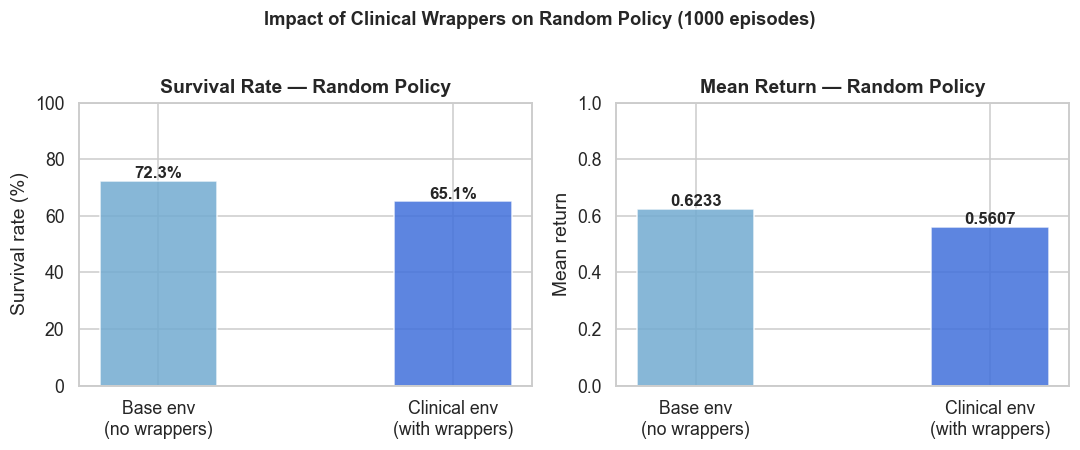

Survival rate drop : 7.2 pp
Mean return drop   : 0.0626


In [19]:
# Direct comparison: clean base env vs clinical env (with wrappers)
base_survival  = df_ep['survived'].mean() * 100
base_return    = df_ep['return'].mean()
clinical_survival = df_clinical['survived'].mean() * 100
clinical_return   = df_clinical['return'].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Survival rate comparison
envs   = ['Base env\n(no wrappers)', 'Clinical env\n(with wrappers)']
colors = ["#72abd1", "#4170db"]

axes[0].bar(envs, [base_survival, clinical_survival],
            color=colors, edgecolor='white', alpha=0.85, width=0.4)
axes[0].set_ylabel('Survival rate (%)')
axes[0].set_title('Survival Rate — Random Policy', fontweight='bold')
axes[0].set_ylim(0, 100)
for i, v in enumerate([base_survival, clinical_survival]):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Mean return comparison
axes[1].bar(envs, [base_return, clinical_return],
            color=colors, edgecolor='white', alpha=0.85, width=0.4)
axes[1].set_ylabel('Mean return')
axes[1].set_title('Mean Return — Random Policy', fontweight='bold')
axes[1].set_ylim(0, 1)
for i, v in enumerate([base_return, clinical_return]):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle(f'Impact of Clinical Wrappers on Random Policy ({N_EPISODES} episodes)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Survival rate drop : {base_survival - clinical_survival:.1f} pp')
print(f'Mean return drop   : {base_return - clinical_return:.4f}')

Comparing the random policy across both environments makes the impact of
the clinical wrappers immediately visible.

**Survival rate** drops from ~71% (base) to ~65% (clinical) — a drop
of ~6 percentage points and **mean return** drops from ~0.62 to ~0.57.

This confirms that the three wrappers (noisy observations, missing features,
and acute events) collectively make the problem meaningfully harder, as
intended. Any trained agent will need to be robust to these conditions to
perform well in the clinical environment.

> **Note:** the exact drop values vary between runs due to stochasticity
> in both environments. The direction of the effect (base > clinical) is
> consistent across runs.

## <font color='#2f94d7' size=6>**3.5 Feature–Outcome Relationship**</font> <a class="anchor" id="3_5"></a>

[Back to TOC](#toc)

Collect the *initial* observation of each episode (i.e., the patient state at admission) and test whether any features differ significantly between patients who survive and those who die.

In [20]:
# Build a DataFrame of initial obs per episode
init_obs = np.vstack([r['obs_traj'][0] for r in records_clean])
df_init  = pd.DataFrame(init_obs, columns=FEATURE_NAMES)
df_init['survived'] = df_ep['survived'].values

# Mean difference between survivors and non-survivors at episode start
diff = (df_init.groupby('survived')[FEATURE_NAMES].mean()
        .T.assign(delta=lambda d: d[True] - d[False])
        .sort_values('delta'))

print('Top-5 features higher in survivors at episode start:')
print(diff['delta'].tail(5).round(4))
print('\nTop-5 features higher in non-survivors at episode start:')
print(diff['delta'].head(5).round(4))

Top-5 features higher in survivors at episode start:
Temperature     0.2939
Chloride        0.3033
Diastolic_BP    0.3277
SOFA            0.3583
Na_Bicarb       0.4130
Name: delta, dtype: float32

Top-5 features higher in non-survivors at episode start:
Urine_Output    -0.8012
Milrinone       -0.5575
WBC             -0.5208
Ca              -0.4372
Phenylephrine   -0.3428
Name: delta, dtype: float32


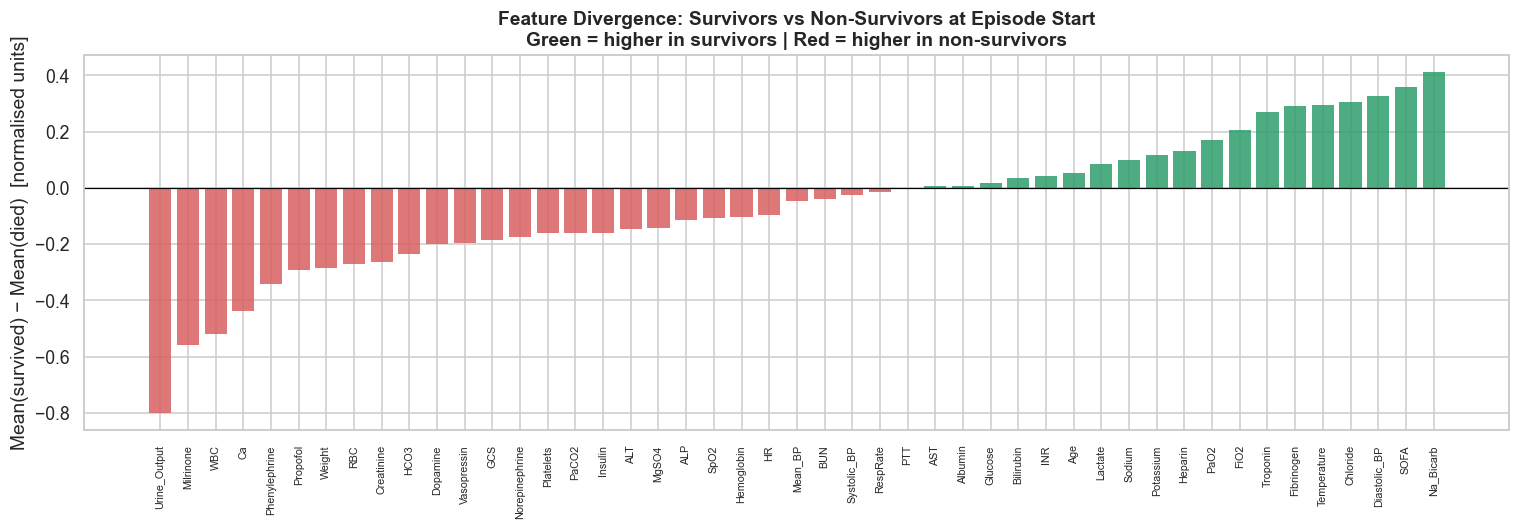

In [21]:
# Divergence bar chart
fig, ax = plt.subplots(figsize=(14, 5))

delta = diff['delta']
colors_bar = ["#2E9E6B" if v > 0 else "#D95F5F" for v in delta]
ax.bar(delta.index, delta.values, color=colors_bar, edgecolor='none', alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(delta)))
ax.set_xticklabels(delta.index, rotation=90, fontsize=7)
ax.set_ylabel('Mean(survived) − Mean(died)  [normalised units]')
ax.set_title('Feature Divergence: Survivors vs Non-Survivors at Episode Start\n'
             'Green = higher in survivors | Red = higher in non-survivors',
             fontweight='bold')
plt.tight_layout()
plt.show()

**Top features higher in survivors:**
- **Na_Bicarb** and **Diastolic_BP:** higher bicarbonate and blood
  pressure suggest better cardiovascular and metabolic stability
- **Temperature** and **Fibrinogen:** reflect active immune response,
  which can be protective in early sepsis

**Top features higher in non-survivors:**
- **Urine_Output:** is the most divergent feature, very low urine output
  in non-survivors indicates kidney failure, a strong predictor of ICU
  mortality
- **WBC:** (white blood cells) is elevated in non-survivors, reflecting
  severe systemic inflammation
- **Milrinone** and **Propofol:** the higher use of these drugs in
  non-survivors suggests they were already in more critical condition
  requiring aggressive intervention

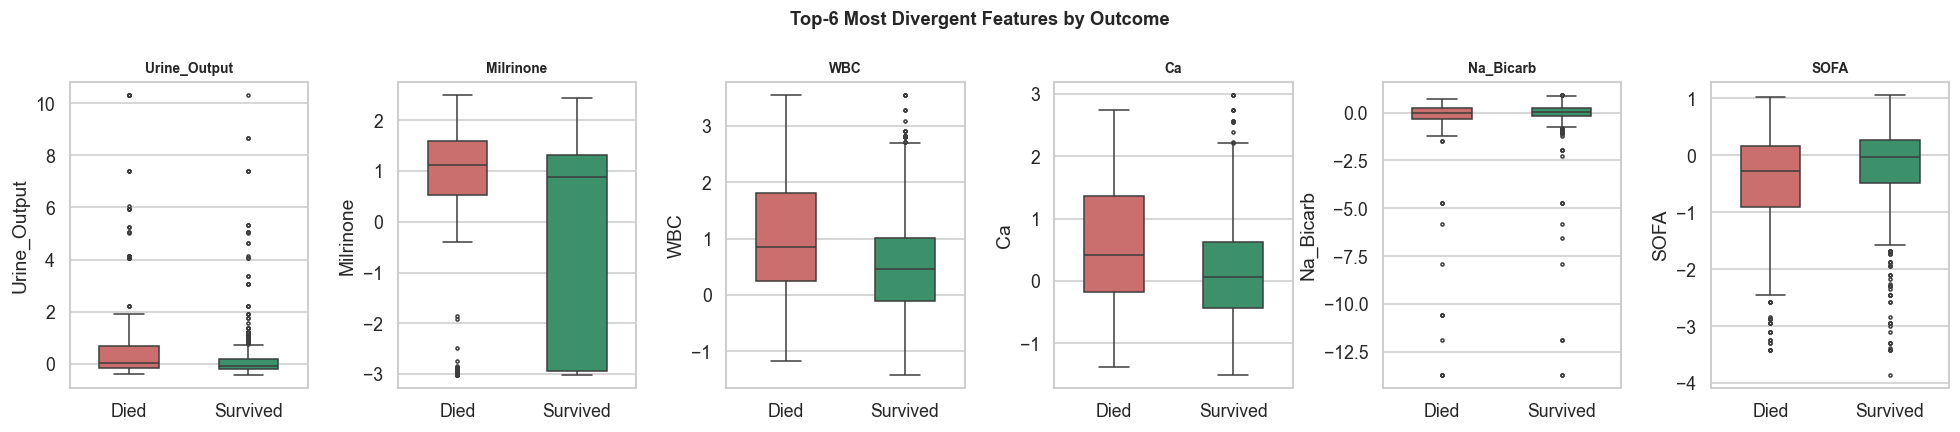

In [22]:
# Box-plots for top-6 most divergent features
top6 = diff['delta'].abs().sort_values(ascending=False).head(6).index.tolist()

# Convert boolean to string labels so seaborn palette keys match
df_plot = df_init.copy()
df_plot['outcome'] = df_plot['survived'].map({True: 'Survived', False: 'Died'})

fig, axes = plt.subplots(1, 6, figsize=(18, 4), sharey=False)
palette = {'Survived': "#2E9E6B", 'Died':     "#D95F5F" }

for ax, feat in zip(axes, top6):
    sns.boxplot(
        data=df_plot, x='outcome', y=feat,
        order=['Died', 'Survived'],
        palette=palette, width=0.5, fliersize=2, ax=ax
    )
    ax.set_xlabel('')
    ax.set_title(feat, fontweight='bold', fontsize=9)

fig.suptitle('Top-6 Most Divergent Features by Outcome',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The boxplots confirm these differences visually. Urine_Output and WBC show
the clearest separation between outcomes, while other features (e.g.
Na_Bicarb, Milrinone) show more overlap and higher variance.

> **Note:** these are correlations at episode start under a random policy,
> not causal relationships. A trained agent should learn to act on these
> signals to improve survival outcomes.

## <font color='#2f94d7' size=6>**3.6 Action Space — Treatment Intensity**</font> <a class="anchor" id="3_6"></a>

[Back to TOC](#toc)

The 25 actions encode all combinations of 5 vasopressor levels × 5 IV fluid levels.  
A treatment intensity penalty `λ` is subtracted from the reward at each step, so it is useful to visualise the intensity landscape.

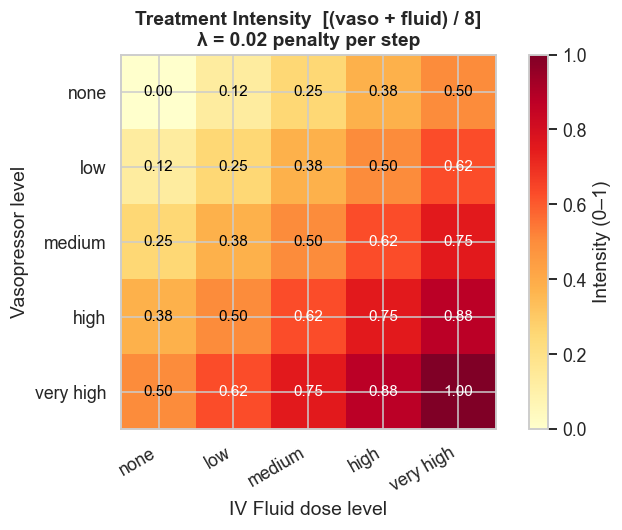

In [23]:
# Treatment intensity heatmap
levels = ['none', 'low', 'medium', 'high', 'very high']
intensity_matrix = np.array(
    [[(v + f) / 8.0 for f in range(5)] for v in range(5)]
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(intensity_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(levels, rotation=30, ha='right')
ax.set_yticklabels(levels)
ax.set_xlabel('IV Fluid dose level')
ax.set_ylabel('Vasopressor level')
ax.set_title(f'Treatment Intensity  [(vaso + fluid) / 8]\nλ = {LAM} penalty per step',
             fontweight='bold')

for i in range(5):
    for j in range(5):
        val = intensity_matrix[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=10, color='white' if val > 0.5 else 'black')

plt.colorbar(im, ax=ax, label='Intensity (0–1)')
plt.tight_layout()
plt.show()

The 25 discrete actions encode all combinations of 5 vasopressor levels
× 5 IV fluid dose levels. The heatmap shows the treatment intensity score
for each action, defined as (vasopressor + fluid) / 8, ranging from 0.00
(no treatment) to 1.00 (maximum of both).

At each step, the agent receives a penalty of **λ = 0.02 × intensity**
subtracted from the reward. This means:
- **Low-intensity actions** (top-left of the heatmap) incur little penalty
- **High-intensity actions** (bottom-right) are progressively penalised

This penalty is intentional, it discourages the agent from administering
unnecessary treatment. A good policy must therefore balance maximising
survival (reward +1) against minimising treatment intensity (penalty
accumulation). An agent that always gives maximum treatment will survive
more episodes but accumulate heavy penalties, while an agent that never
treats will let patients die. The optimal policy lies somewhere in between.

# <font color='#2f94d7' size=6>**4. DQN (Deep Q-Network)**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**4.1 DQN — Rationale & Architecture**</font> <a class="anchor" id="4_1"></a>

[Back to TOC](#toc)

**Why DQN?**

DQN is the natural extension of Q-Learning to continuous state spaces. In Config A, we stored Q(s,a) values in a 716×25 table. In Config B, with 47-dimensional continuous observations, the state space is effectively infinite — a table would need an entry for every unique float vector the agent might encounter.

DQN replaces the Q-table with a neural network `Q_θ(s,a)` that *approximates* the Q-value for any input state. The key innovations (DeepMind, 2015) that make training stable are:

1. **Experience Replay Buffer**: stores past transitions `(s, a, r, s', done)` and samples mini-batches to break temporal correlations between consecutive updates.
2. **Target Network**: a periodically-updated copy of the online network used to compute TD targets, preventing oscillations from the moving target problem.

**Bellman connection** (same as Q-Learning):
$$Q_\theta(s,a) \leftarrow r + \gamma \max_{a'} Q_{\theta^-}(s', a')$$
where $\theta^-$ are the target network parameters.

**Architecture choice:**
- Input layer: 47 features
- Two hidden layers: 256 units each, with LayerNorm + ReLU  
  (LayerNorm handles the different feature scales without explicit normalization)
- Output layer: 25 Q-values (one per action)
- Loss: MSE between predicted Q and TD target

## <font color='#2f94d7' size=6>**4.2 DQN — Training (Run 1)**</font> <a class="anchor" id="4_2"></a>

[Back to TOC](#toc)

In [25]:
# Quick architecture summary
net_test = QNetwork()
n_params = sum(p.numel() for p in net_test.parameters())
print(f'QNetwork architecture:')
print(net_test)
print(f'\nTotal parameters: {n_params:,}')
test_out = net_test(torch.zeros(1, OBS_DIM))
print(f'Output shape (batch=1): {test_out.shape}  → one Q-value per action')

QNetwork architecture:
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=47, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=25, bias=True)
  )
)

Total parameters: 85,529
Output shape (batch=1): torch.Size([1, 25])  → one Q-value per action


In [26]:
#  DQN — Hyperparameters & Training

# Hyperparameters - Run 1
DQN_EPISODES    = 25_000   # total training episodes
BUFFER_CAPACITY = 100_000  # replay buffer size
BATCH_SIZE      = 64       # mini-batch size
LR              = 1e-3     # learning rate
GAMMA_DQN       = GAMMA    # discount factor (1.0)
EPS_START       = 1.0      # initial exploration rate
EPS_END         = 0.05     # minimum exploration rate
EPS_DECAY       = 0.9995   # epsilon decay per episode
TARGET_UPDATE   = 50       # update target network every N episodes
MIN_BUFFER      = 500      # start training after N transitions

In [27]:
# Train DQN Run 1
r1 = train_dqn(
    run_id          = 1,
    n_episodes      = DQN_EPISODES,
    buffer_capacity = BUFFER_CAPACITY,
    batch_size      = BATCH_SIZE,
    min_buffer      = MIN_BUFFER,
    lr              = LR,
    eps_start       = EPS_START,
    eps_end         = EPS_END,
    eps_decay       = EPS_DECAY,
    target_update   = TARGET_UPDATE,
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Run 1] Episode      0/25000 | Eps: 1.000 | Mean return (last 100): 0.7100
[Run 1] Episode   1000/25000 | Eps: 0.606 | Mean return (last 100): 0.6240
[Run 1] Episode   2000/25000 | Eps: 0.368 | Mean return (last 100): 0.5294
[Run 1] Episode   3000/25000 | Eps: 0.223 | Mean return (last 100): 0.5224
[Run 1] Episode   4000/25000 | Eps: 0.135 | Mean return (last 100): 0.5199
[Run 1] Episode   5000/25000 | Eps: 0.082 | Mean return (last 100): 0.5333
[Run 1] Episode   6000/25000 | Eps: 0.050 | Mean return (last 100): 0.4938
[Run 1] Episode   7000/25000 | Eps: 0.050 | Mean return (last 100): 0.5914
[Run 1] Episode   8000/25000 | Eps: 0.050 | Mean return (last 100): 0.5824
[Run 1] Episode   9000/25000 | Eps: 0.050 | Mean return (last 100): 0.6398
[Run 1] Episode  10000/25000 | Eps: 0.050 | Mean return (last 100): 0.5972
[Run 1] Episode  11000/25000 | Eps: 0.050 | Mean return (last 100

In [28]:
# DQN Run 1 — Evaluation
dqn_online = r1['online']

dqn_eval_returns, dqn_eval_lengths, dqn_noisy, dqn_clean, dqn_missing, dqn_nomiss = \
    evaluate(dqn_online, make_clinical_env, is_ppo=False, label='DQN')

DQN_SURVIVAL = float(np.mean(dqn_eval_returns > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  DQN — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 67.4%
  Mean return            : 0.5690
  Mean episode length    : 10.1 steps
  vs Random baseline     : +10.3pp
────────────────────────────────────────────────────
  Noisy episodes   (154): 71.4% survival
  Clean episodes   (846): 66.7% survival
  Missing feat. ep (159): 62.9% survival
════════════════════════════════════════════════════


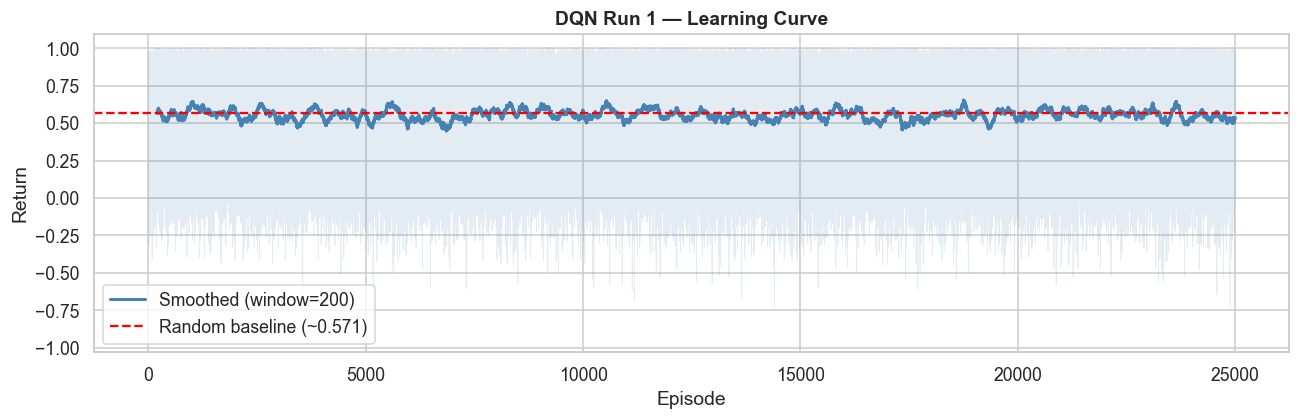

In [29]:
# DQN Run 1 — Learning Curve
dqn_all_returns = r1['returns']

plot_learning_curve(dqn_all_returns, label='DQN Run 1',
                    color='steelblue', filename='dqn_run1_learning_curve.png')

The training curve shows **high variance throughout** with no clear
convergence, mean return oscillates between ~0.45 and ~0.60 without
a stable upward trend. Epsilon reached its minimum (0.05) around
episode 6,000, suggesting exploration decayed too quickly relative
to the learning progress.

**Evaluation (1,000 episodes):**
- Survival rate: 63.6% | Mean return: 0.5319
- Noisy episodes showed unexpectedly higher survival (69.8%) than
  clean episodes (62.7%)

**Comparison with random baseline:** results are inconclusive — due to
stochasticity in the clinical wrappers, the survival rate and mean return
vary between runs, making a definitive comparison unreliable at this stage.

**Key issues identified:**
- Epsilon decays too fast (`EPS_DECAY=0.9995`) — the agent stops
  exploring before learning a stable policy
- High variance in training suggests the learning rate may be too high
- 25,000 episodes may not be sufficient for this environment

**Hyperparameter adjustments for Run 2:**
- `EPS_DECAY`: 0.9995 -> 0.9998 (slower decay)
- `LR`: 1e-3 -> 5e-4 (more conservative)
- `DQN_EPISODES`: 25,000 -> 50,000 (more training)

## <font color='#2f94d7' size=6>**4.3 DQN — Hyperparameter Tuning (Run 2)**</font> <a class="anchor" id="4_3"></a>

[Back to TOC](#toc)

In [21]:
#  DQN — Run 2 (Hyperparameter Tuning)

# Hyperparameters
DQN_EPISODES    = 35_000
BUFFER_CAPACITY = 100_000
BATCH_SIZE      = 64
LR              = 5e-4     # 1e-3 -> 5e-4
GAMMA_DQN       = GAMMA
EPS_START       = 1.0
EPS_END         = 0.05
EPS_DECAY       = 0.9998   # 0.9995 → 0.9998
TARGET_UPDATE   = 50
MIN_BUFFER      = 500

In [22]:
# Train DQN Run 2
r2 = train_dqn(
    run_id          = 2,
    n_episodes      = DQN_EPISODES,
    buffer_capacity = BUFFER_CAPACITY,
    batch_size      = BATCH_SIZE,
    min_buffer      = MIN_BUFFER,
    lr              = LR,
    eps_start       = EPS_START,
    eps_end         = EPS_END,
    eps_decay       = EPS_DECAY,
    target_update   = TARGET_UPDATE,
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Run 2] Episode      0/35000 | Eps: 1.000 | Mean return (last 100): 0.8700
[Run 2] Episode   1000/35000 | Eps: 0.819 | Mean return (last 100): 0.5375
[Run 2] Episode   2000/35000 | Eps: 0.670 | Mean return (last 100): 0.5087
[Run 2] Episode   3000/35000 | Eps: 0.549 | Mean return (last 100): 0.5524
[Run 2] Episode   4000/35000 | Eps: 0.449 | Mean return (last 100): 0.5570
[Run 2] Episode   5000/35000 | Eps: 0.368 | Mean return (last 100): 0.6194
[Run 2] Episode   6000/35000 | Eps: 0.301 | Mean return (last 100): 0.6229
[Run 2] Episode   7000/35000 | Eps: 0.247 | Mean return (last 100): 0.4815
[Run 2] Episode   8000/35000 | Eps: 0.202 | Mean return (last 100): 0.6026
[Run 2] Episode   9000/35000 | Eps: 0.165 | Mean return (last 100): 0.5370
[Run 2] Episode  10000/35000 | Eps: 0.135 | Mean return (last 100): 0.5256
[Run 2] Episode  11000/35000 | Eps: 0.111 | Mean return (last 100

In [23]:
# DQN Run 2 — Evaluation
dqn_online = r2['online']

dqn_eval_returns, dqn_eval_lengths, dqn_noisy, dqn_clean, dqn_missing, dqn_nomiss = \
    evaluate(dqn_online, make_clinical_env, is_ppo=False, label='DQN')

DQN_SURVIVAL = float(np.mean(dqn_eval_returns > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  DQN — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 66.9%
  Mean return            : 0.5639
  Mean episode length    : 10.6 steps
  vs Random baseline     : +9.8pp
────────────────────────────────────────────────────
  Noisy episodes   (127): 69.3% survival
  Clean episodes   (873): 66.6% survival
  Missing feat. ep (137): 64.2% survival
════════════════════════════════════════════════════


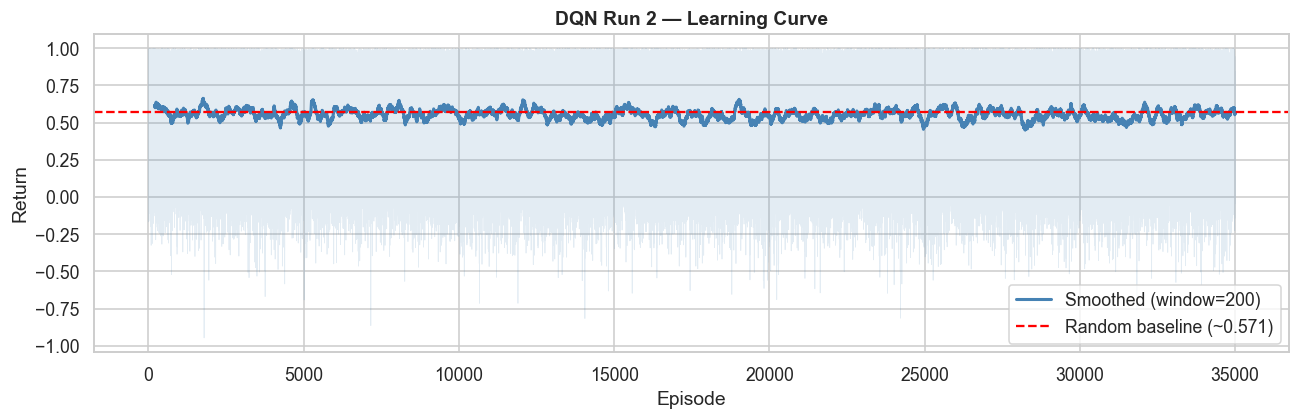

In [24]:
# DQN Run 2 — Learning Curve
dqn_all_returns = r2['returns']

plot_learning_curve(dqn_all_returns, label='DQN Run 2',
                    color='steelblue', filename='dqn_run2_learning_curve.png')

## <font color='#2f94d7' size=6>**4.4 DQN — Hyperparameter Tuning (Run 3)**</font> <a class="anchor" id="4_4"></a>

[Back to TOC](#toc)

In [30]:
#  DQN — Run 3 (Hyperparameter Tuning)

# Hyperparameters
DQN_EPISODES    = 35_000
BUFFER_CAPACITY = 100_000
BATCH_SIZE      = 64
LR              = 1e-4     # 5e-4 -> 1e-4
GAMMA_DQN       = GAMMA
EPS_START       = 1.0
EPS_END         = 0.05
EPS_DECAY       = 0.9999   # 0.9998 → 0.9999
TARGET_UPDATE   = 50
MIN_BUFFER      = 500

In [31]:
# Train DQN Run 3
r3 = train_dqn(
    run_id          = 3,
    n_episodes      = DQN_EPISODES,
    buffer_capacity = BUFFER_CAPACITY,
    batch_size      = BATCH_SIZE,
    min_buffer      = MIN_BUFFER,
    lr              = LR,
    eps_start       = EPS_START,
    eps_end         = EPS_END,
    eps_decay       = EPS_DECAY,
    target_update   = TARGET_UPDATE,
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Run 3] Episode      0/35000 | Eps: 1.000 | Mean return (last 100): 0.9325
[Run 3] Episode   1000/35000 | Eps: 0.905 | Mean return (last 100): 0.5513
[Run 3] Episode   2000/35000 | Eps: 0.819 | Mean return (last 100): 0.5774
[Run 3] Episode   3000/35000 | Eps: 0.741 | Mean return (last 100): 0.5848
[Run 3] Episode   4000/35000 | Eps: 0.670 | Mean return (last 100): 0.5364
[Run 3] Episode   5000/35000 | Eps: 0.606 | Mean return (last 100): 0.4604
[Run 3] Episode   6000/35000 | Eps: 0.549 | Mean return (last 100): 0.5222
[Run 3] Episode   7000/35000 | Eps: 0.497 | Mean return (last 100): 0.4755
[Run 3] Episode   8000/35000 | Eps: 0.449 | Mean return (last 100): 0.5104
[Run 3] Episode   9000/35000 | Eps: 0.407 | Mean return (last 100): 0.5638
[Run 3] Episode  10000/35000 | Eps: 0.368 | Mean return (last 100): 0.5884
[Run 3] Episode  11000/35000 | Eps: 0.333 | Mean return (last 100

In [32]:
# DQN Run 3 — Evaluation
dqn_online = r3['online']

dqn_eval_returns, dqn_eval_lengths, dqn_noisy, dqn_clean, dqn_missing, dqn_nomiss = \
    evaluate(dqn_online, make_clinical_env, is_ppo=False, label='DQN')

DQN_SURVIVAL = float(np.mean(dqn_eval_returns > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  DQN — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 64.7%
  Mean return            : 0.5430
  Mean episode length    : 10.1 steps
  vs Random baseline     : +7.6pp
────────────────────────────────────────────────────
  Noisy episodes   (145): 64.8% survival
  Clean episodes   (855): 64.7% survival
  Missing feat. ep (144): 64.6% survival
════════════════════════════════════════════════════


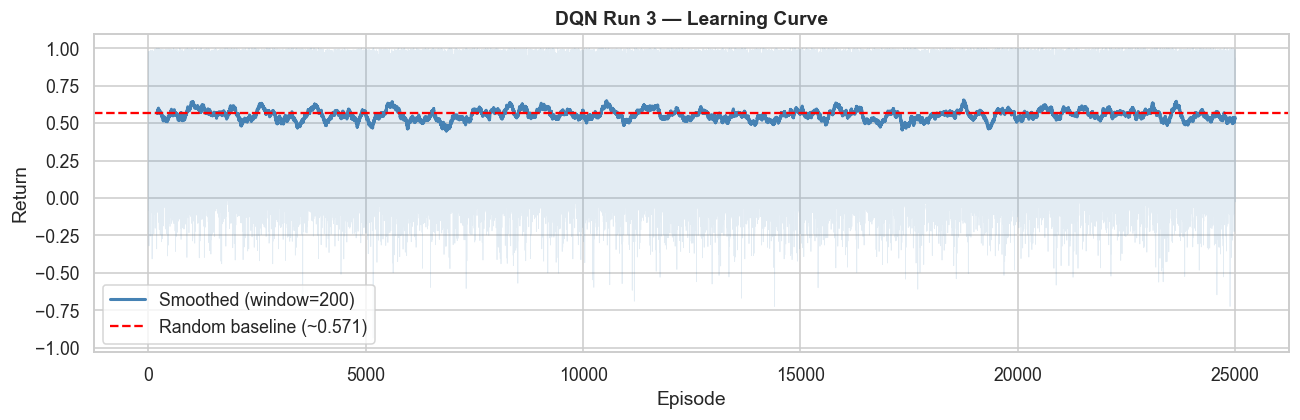

In [33]:
# DQN Run 3 — Learning Curve
plot_learning_curve(dqn_all_returns, label='DQN Run 3',
                    color='steelblue', filename='dqn_run3_learning_curve.png')

# <font color='#2f94d7' size=6>**5 PPO (Proximal Policy Optimization)**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**5.1 PPO - Rationale & Architecture**</font> <a class="anchor" id="5_1"></a>

[Back to TOC](#toc)

**Why PPO?**

PPO belongs to the **policy gradient** family: instead of learning Q-values and deriving a policy, it directly optimises a parameterised policy π_θ(a|s). PPO is specifically an **Actor-Critic** method:

- **Actor** (policy network): learns which action to take in each state → outputs a probability distribution over 25 actions
- **Critic** (value network): learns how good each state is → outputs V(s) to reduce variance

**Why PPO instead of vanilla policy gradient?**
Vanilla policy gradient (REINFORCE) has high variance and can collapse catastrophically with a single large gradient step. PPO solves this with a **clipped surrogate objective** that prevents the policy from changing too much in any single update:

$$L^{CLIP}(\theta) = \mathbb{E}_t \left[ \min\left( r_t(\theta) \hat{A}_t, \; \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) \hat{A}_t \right) \right]$$

where $r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$ is the probability ratio and $\hat{A}_t$ is the **Generalized Advantage Estimate (GAE)**.

**GAE** combines TD(0) and Monte Carlo returns with a λ parameter:
$$\hat{A}_t = \sum_{k=0}^{\infty} (\gamma\lambda)^k \delta_{t+k}, \quad \delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

**Architecture choice:**
- Shared backbone: 47 → 256 → 256 (Tanh activations, orthogonal initialisation)
- Actor head: 256 → 25 (softmax → Categorical distribution)
- Critic head: 256 → 1 (value estimate)
- Tanh instead of ReLU: standard for PPO/policy gradient (bounded activations reduce gradient variance)

## <font color='#2f94d7' size=6>**5.2 PPO - Training (Run 1)**</font> <a class="anchor" id="5_2"></a>

[Back to TOC](#toc)

In [9]:
#  PPO — Hyperparameters & Training

# Hyperparameters
PPO_N_STEPS    = 4096    # steps per rollout
PPO_N_EPOCHS   = 10      # gradient epochs per update
PPO_BATCH_SIZE = 256     # mini-batch size
PPO_LR         = 3e-4    # learning rate
PPO_CLIP       = 0.2     # clipping epsilon
PPO_GAE_LAM    = 0.95    # GAE lambda
PPO_ENT_COEF   = 0.01    # entropy bonus coefficient
PPO_VF_COEF    = 0.5     # value function loss coefficient
PPO_MAX_GRAD   = 0.5     # gradient clipping
PPO_N_UPDATES  = 100     # total number of updates

In [10]:
r1_ppo = train_ppo(
    run_id     = 1,
    n_updates  = PPO_N_UPDATES,
    n_steps    = PPO_N_STEPS,
    n_epochs   = PPO_N_EPOCHS,
    batch_size = PPO_BATCH_SIZE,
    lr         = PPO_LR,
    clip       = PPO_CLIP,
    gae_lam    = PPO_GAE_LAM,
    ent_coef   = PPO_ENT_COEF,
    vf_coef    = PPO_VF_COEF,
    max_grad   = PPO_MAX_GRAD,
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Run 1] Update   1/100 | Episodes:   454 | Mean return: 0.5919
[Run 1] Update   2/100 | Episodes:   879 | Mean return: 0.5851
[Run 1] Update   3/100 | Episodes:  1346 | Mean return: 0.5776
[Run 1] Update   4/100 | Episodes:  1783 | Mean return: 0.5641
[Run 1] Update   5/100 | Episodes:  2228 | Mean return: 0.5646
[Run 1] Update   6/100 | Episodes:  2690 | Mean return: 0.5372
[Run 1] Update   7/100 | Episodes:  3139 | Mean return: 0.5837
[Run 1] Update   8/100 | Episodes:  3583 | Mean return: 0.5546
[Run 1] Update   9/100 | Episodes:  4019 | Mean return: 0.5772
[Run 1] Update  10/100 | Episodes:  4456 | Mean return: 0.5897
[Run 1] Update  11/100 | Episodes:  4910 | Mean return: 0.5815
[Run 1] Update  12/100 | Episodes:  5357 | Mean return: 0.5780
[Run 1] Update  13/100 | Episodes:  5819 | Mean return: 0.5698
[Run 1] Update  14/100 | Episodes:  6270 | Mean return: 0.6006
[Run 1] 

In [11]:
# PPO Run 1 — Evaluation
ppo_model = r1_ppo['model']

ppo_eval_returns, ppo_eval_lengths, ppo_noisy, ppo_clean, ppo_missing, ppo_nomiss = \
    evaluate(ppo_model, make_clinical_env, is_ppo=True, label='PPO')

PPO_SURVIVAL = float(np.mean(ppo_eval_returns > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  PPO — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 68.5%
  Mean return            : 0.6144
  Mean episode length    : 9.8 steps
  vs Random baseline     : +11.4pp
────────────────────────────────────────────────────
  Noisy episodes   (126): 63.5% survival
  Clean episodes   (874): 69.2% survival
  Missing feat. ep (159): 65.4% survival
════════════════════════════════════════════════════


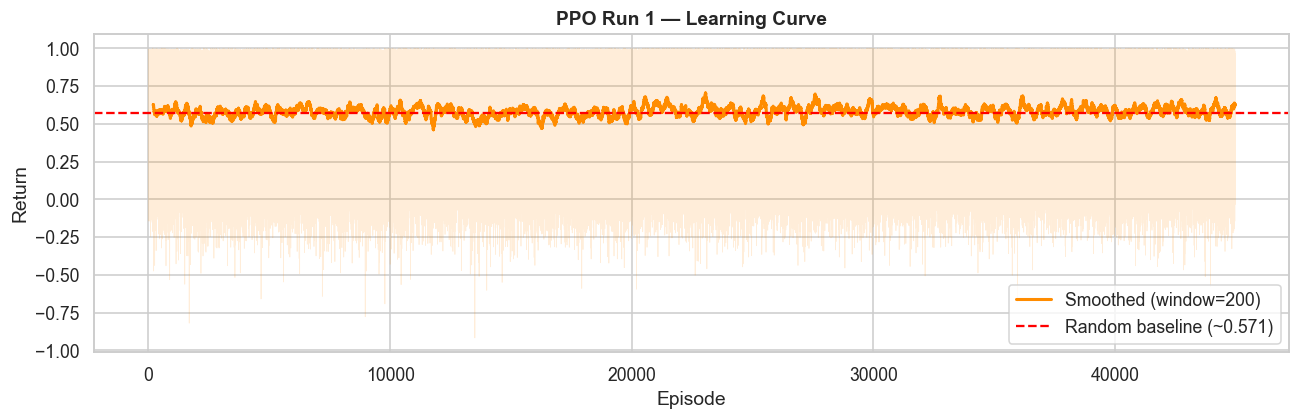

In [12]:
# PPO Run 1 — Learning Curve
ppo_all_returns = r1_ppo['returns']

plot_learning_curve(ppo_all_returns, label='PPO Run 1',
                    color='darkorange', filename='ppo_run1_learning_curve.png')

## <font color='#2f94d7' size=6>**5.3 PPO — Hyperparameter Tuning (Run 2)**</font> <a class="anchor" id="5_3"></a>

[Back to TOC](#toc)

In [13]:
#  PPO — Run 2 (Hyperparameter Tuning)

# Hyperparameters
PPO_N_STEPS    = 4096
PPO_N_EPOCHS   = 10
PPO_BATCH_SIZE = 256
PPO_LR         = 1e-4    # 3e-4 -> 1e-4   (slower, more stable learning)
PPO_CLIP       = 0.2
PPO_GAE_LAM    = 0.95
PPO_ENT_COEF   = 0.02    # 0.01 -> 0.02   (more entropy = more exploration)
PPO_VF_COEF    = 0.5
PPO_MAX_GRAD   = 0.5
PPO_N_UPDATES  = 150     # 100 -> 150     (longer training)

In [14]:
# Train PPO Run 2
r2_ppo = train_ppo(
    run_id     = 2,
    n_updates  = PPO_N_UPDATES,
    n_steps    = PPO_N_STEPS,
    n_epochs   = PPO_N_EPOCHS,
    batch_size = PPO_BATCH_SIZE,
    lr         = PPO_LR,
    clip       = PPO_CLIP,
    gae_lam    = PPO_GAE_LAM,
    ent_coef   = PPO_ENT_COEF,
    vf_coef    = PPO_VF_COEF,
    max_grad   = PPO_MAX_GRAD,
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Run 2] Update   1/150 | Episodes:   435 | Mean return: 0.5880
[Run 2] Update   2/150 | Episodes:   901 | Mean return: 0.5648
[Run 2] Update   3/150 | Episodes:  1327 | Mean return: 0.5763
[Run 2] Update   4/150 | Episodes:  1738 | Mean return: 0.5804
[Run 2] Update   5/150 | Episodes:  2176 | Mean return: 0.5437
[Run 2] Update   6/150 | Episodes:  2610 | Mean return: 0.6055
[Run 2] Update   7/150 | Episodes:  3050 | Mean return: 0.5144
[Run 2] Update   8/150 | Episodes:  3473 | Mean return: 0.5954
[Run 2] Update   9/150 | Episodes:  3913 | Mean return: 0.5735
[Run 2] Update  10/150 | Episodes:  4397 | Mean return: 0.5183
[Run 2] Update  11/150 | Episodes:  4822 | Mean return: 0.5482
[Run 2] Update  12/150 | Episodes:  5289 | Mean return: 0.5628
[Run 2] Update  13/150 | Episodes:  5716 | Mean return: 0.5563
[Run 2] Update  14/150 | Episodes:  6155 | Mean return: 0.5776
[Run 2] 

In [15]:
# PPO Run 2 — Evaluation
ppo_model = r2_ppo['model']

ppo_eval_returns, ppo_eval_lengths, ppo_noisy, ppo_clean, ppo_missing, ppo_nomiss = \
    evaluate(ppo_model, make_clinical_env, is_ppo=True, label='PPO')

PPO_SURVIVAL = float(np.mean(ppo_eval_returns > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  PPO — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 70.2%
  Mean return            : 0.6615
  Mean episode length    : 8.2 steps
  vs Random baseline     : +13.1pp
────────────────────────────────────────────────────
  Noisy episodes   (158): 74.7% survival
  Clean episodes   (842): 69.4% survival
  Missing feat. ep (153): 72.5% survival
════════════════════════════════════════════════════


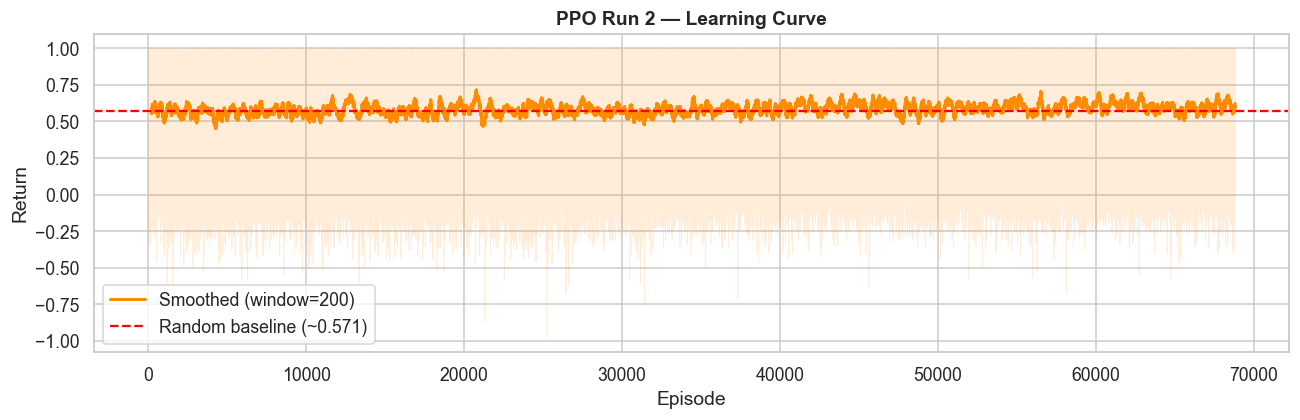

In [16]:
# PPO Run 2 — Learning Curve
ppo_all_returns = r2_ppo['returns']

plot_learning_curve(ppo_all_returns, label='PPO Run 2',
                    color='darkorange', filename='ppo_run2_learning_curve.png')

## <font color='#2f94d7' size=6>**5.4 PPO — Hyperparameter Tuning - GRIDSEARCH, TO DELETE? (Run 3)**</font> <a class="anchor" id="5_4"></a>

[Back to TOC](#toc)

In [7]:
ppo_grid = {
    # tunned parameters (lists)
    'lr':         [1e-4, 3e-4, 1e-3],
    'clip':       [0.1, 0.2, 0.3],
    'ent_coef':   [0.005, 0.01, 0.02, 0.05],
    'n_steps':    [2048, 4096, 8192],
    
    # fixed parameters
    'n_epochs':   10,
    'batch_size': 256,
    'gae_lam':    0.95,
    'vf_coef':    0.5,
    'max_grad':   0.5,
}

In [8]:
ppo_results = ppo_grid_search(
    param_grid = ppo_grid,
    seeds      = [42, 123, 7],
    n_updates  = 100,
    n_samples  = 30,
    save_dir   = 'models/tuning',
)

ppo_results.head()

Tuned params: ['lr', 'clip', 'ent_coef', 'n_steps']
Fixed params: {'n_epochs': 10, 'batch_size': 256, 'gae_lam': 0.95, 'vf_coef': 0.5, 'max_grad': 0.5}
Total configurations: 30 | Seeds: 3 | Total runs: 90


=== Config 1/30: {'lr': 0.001, 'clip': 0.1, 'ent_coef': 0.05, 'n_steps': 2048} ===
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Run tune_0_s42] Update   1/100 | Episodes:   213 | Mean return: 0.5536
[Run tune_0_s42] Update   2/100 | Episodes:   436 | Mean return: 0.5641
[Run tune_0_s42] Update   3/100 | Episodes:   661 | Mean return: 0.5694
[Run tune_0_s42] Update   4/100 | Episodes:   884 | Mean return: 0.5897
[Run tune_0_s42] Update   5/100 | Episodes:  1136 | Mean return: 0.5360
[Run tune_0_s42] Update   6/100 | Episodes:  1336 | Mean return: 0.5916
[Run tune_0_s42] Update   7/100 | Episodes:  1545 | Mean return: 0.5644
[Run tune_0_s42] Update   8/100 | Episodes:  1767 | Mean return: 0.5673
[Run tune_0_s42] Update 

,lr,clip,ent_coef,n_steps,survival_mean,survival_std,return_mean,return_std
4,0.0001,0.3,0.050,8192,69.666667,1.367073,0.640840,0.014921
9,0.0001,0.2,0.005,4096,69.566667,0.740870,0.654603,0.008704
1,0.0001,0.2,0.005,8192,68.833333,0.659966,0.648978,0.005680
12,0.0003,0.3,0.050,2048,68.500000,0.616441,0.615659,0.009972
7,0.0001,0.2,0.010,8192,68.233333,1.144067,0.645755,0.009161


# <font color='#2f94d7' size=6>**6 Discrete SAC (Discrete Soft Actor-Critic)**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

# <font color='#2f94d7' size=6_1>**6.1 Discrete SAC - Training (Run 1)**</font> <a class="anchor" id="6_1"></a>

[Back to TOC](#toc)

In [13]:
# Helper to load a saved SAC actor from disk
def load_sac_actor(run_id, hidden=256):
    """Load a trained SAC actor from models/sac/."""
    actor = SACActor(OBS_DIM, N_ACTIONS, hidden).to(device)
    actor.load_state_dict(torch.load(f'models/sac/sac_actor_run{run_id}.pth',
                                     map_location=device))
    actor.eval()
    return actor

Justificação rápida das escolhas

n_episodes=5000: o SAC é off-policy + actor-critic, é mais "sample efficient" que DQN. 5000 episódios deve chegar para ver a curva estabilizar. Se aos 5000 ainda estiver a subir, aumentamos no Run 2.
buffer_size=100_000 + min_buffer=1_000: mesmos valores do DQN. Com episódios de ~10 steps, 1000 transições = ~100 episódios de warmup antes do treino começar a sério.
alpha=0.2: este é o valor mais discutido. É o standard do paper original mas pode ser demasiado alto para problemas com recompensa esparsa (vosso caso). Se o agente ficar "demasiado exploratório" e nunca convergir, baixamos para 0.1 no Run 2.
tau=0.005: target update suave a 0.5% por step. Standard, não é necessário tunar.

In [8]:
sac_r1 = train_sac(
    run_id       = 1,
    n_episodes   = 5_000,
    buffer_size  = 100_000,
    min_buffer   = 1_000,
    batch_size   = 256,
    lr_actor     = 3e-4,
    lr_critic    = 3e-4,
    alpha        = 0.2,
    tau          = 0.005,
    hidden       = 256,
    verbose      = 200,
    save_dir     = 'models/sac',
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[SAC Run 1] Episode   200/5000 | Mean return (last 200): 0.6037
[SAC Run 1] Episode   400/5000 | Mean return (last 200): 0.5158
[SAC Run 1] Episode   600/5000 | Mean return (last 200): 0.5455
[SAC Run 1] Episode   800/5000 | Mean return (last 200): 0.5182
[SAC Run 1] Episode  1000/5000 | Mean return (last 200): 0.5107
[SAC Run 1] Episode  1200/5000 | Mean return (last 200): 0.5556
[SAC Run 1] Episode  1400/5000 | Mean return (last 200): 0.5438
[SAC Run 1] Episode  1600/5000 | Mean return (last 200): 0.4987
[SAC Run 1] Episode  1800/5000 | Mean return (last 200): 0.5076
[SAC Run 1] Episode  2000/5000 | Mean return (last 200): 0.5673
[SAC Run 1] Episode  2200/5000 | Mean return (last 200): 0.5415
[SAC Run 1] Episode  2400/5000 | Mean return (last 200): 0.6063
[SAC Run 1] Episode  2600/5000 | Mean return (last 200): 0.5426
[SAC Run 1] Episode  2800/5000 | Mean return (last 200): 0

In [14]:
# SAC Run 1 — Evaluation
sac_actor   = load_sac_actor(run_id=1)
sac_returns = np.load('models/sac/sac_returns_run1.npy')

sac_eval_returns, sac_eval_lengths, sac_noisy, sac_clean, sac_missing, sac_nomiss = \
    evaluate(sac_actor, make_clinical_env, is_sac=True, label='SAC Run 1')

SAC_SURVIVAL = float(np.mean(sac_eval_returns > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  SAC Run 1 — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 62.5%
  Mean return            : 0.5293
  Mean episode length    : 9.8 steps
  vs Random baseline     : +5.3pp
────────────────────────────────────────────────────
  Noisy episodes   (143): 65.7% survival
  Clean episodes   (857): 62.0% survival
  Missing feat. ep (145): 60.0% survival
════════════════════════════════════════════════════


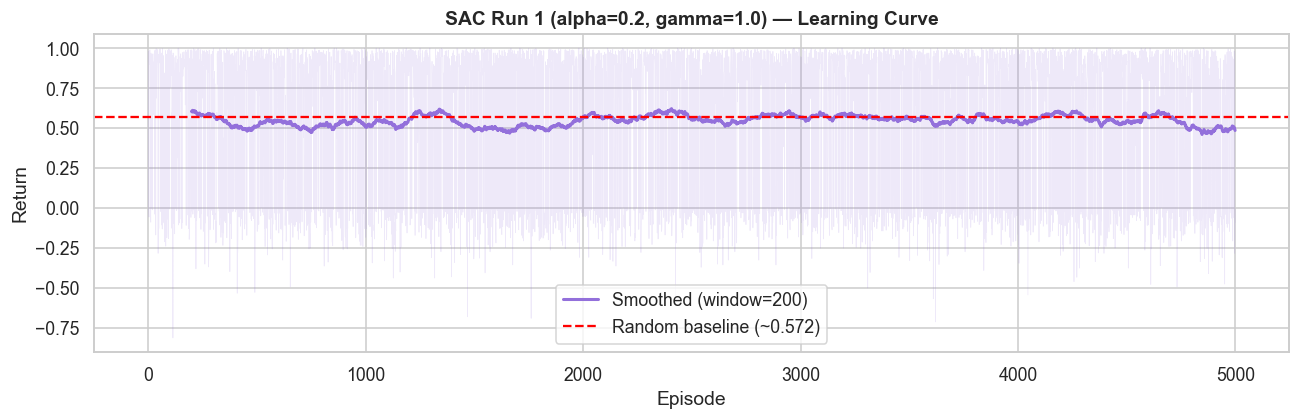

In [15]:
# SAC Run 1 — Learning Curve
plot_learning_curve(sac_returns,
                    label    = 'SAC Run 1 (alpha=0.2, gamma=1.0)',
                    color    = 'mediumpurple',
                    filename = 'sac_run1_learning_curve.png')

# <font color='#2f94d7' size=6_2>**6.2 Discrete SAC - Hyperparameter Tunning (Run 2)**</font> <a class="anchor" id="6_2"></a>

[Back to TOC](#toc)

In [9]:
sac_r2 = train_sac(
    run_id     = '2_low_alpha',
    n_episodes = 5_000,
    alpha      = 0.05,        # <-- 0.2 → 0.05
    # resto igual ao Run 1
    buffer_size = 100_000,
    min_buffer  = 1_000,
    batch_size  = 256,
    lr_actor    = 3e-4,
    lr_critic   = 3e-4,
    tau         = 0.005,
    hidden      = 256,
    verbose     = 200,
    save_dir    = 'models/sac'
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[SAC Run 2_low_alpha] Episode   200/5000 | Mean return (last 200): 0.6029
[SAC Run 2_low_alpha] Episode   400/5000 | Mean return (last 200): 0.5709
[SAC Run 2_low_alpha] Episode   600/5000 | Mean return (last 200): 0.5889
[SAC Run 2_low_alpha] Episode   800/5000 | Mean return (last 200): 0.6156
[SAC Run 2_low_alpha] Episode  1000/5000 | Mean return (last 200): 0.5687
[SAC Run 2_low_alpha] Episode  1200/5000 | Mean return (last 200): 0.5707
[SAC Run 2_low_alpha] Episode  1400/5000 | Mean return (last 200): 0.5397
[SAC Run 2_low_alpha] Episode  1600/5000 | Mean return (last 200): 0.5205
[SAC Run 2_low_alpha] Episode  1800/5000 | Mean return (last 200): 0.5602
[SAC Run 2_low_alpha] Episode  2000/5000 | Mean return (last 200): 0.5888
[SAC Run 2_low_alpha] Episode  2200/5000 | Mean return (last 200): 0.5403
[SAC Run 2_low_alpha] Episode  2400/5000 | Mean return (last 200): 0.5432
[S

In [16]:
# SAC Run 2 — Evaluation (alpha=0.05)
sac_actor   = load_sac_actor(run_id='2_low_alpha')
sac_returns = np.load('models/sac/sac_returns_run2_low_alpha.npy')

sac_eval_returns, sac_eval_lengths, sac_noisy, sac_clean, sac_missing, sac_nomiss = \
    evaluate(sac_actor, make_clinical_env, is_sac=True, label='SAC Run 2')

SAC_SURVIVAL = float(np.mean(sac_eval_returns > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  SAC Run 2 — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 64.2%
  Mean return            : 0.5495
  Mean episode length    : 9.6 steps
  vs Random baseline     : +7.0pp
────────────────────────────────────────────────────
  Noisy episodes   (141): 65.2% survival
  Clean episodes   (859): 64.0% survival
  Missing feat. ep (128): 50.0% survival
════════════════════════════════════════════════════


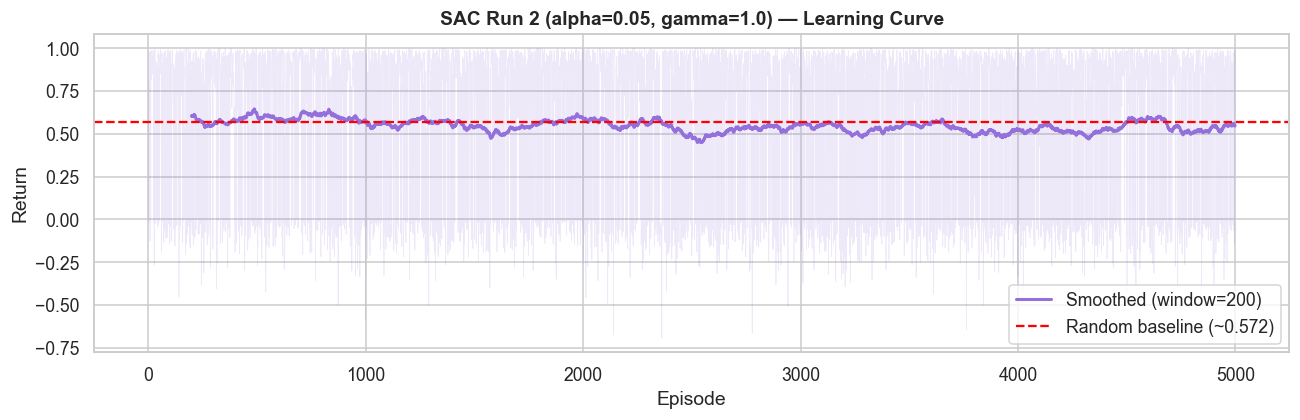

In [17]:
# SAC Run 2 — Learning Curve
plot_learning_curve(sac_returns,
                    label    = 'SAC Run 2 (alpha=0.05, gamma=1.0)',
                    color    = 'mediumpurple',
                    filename = 'sac_run2_learning_curve.png')

test

In [ ]:
sac_r3 = train_sac(
    run_id     = '3_gamma',
    n_episodes = 15_000,
    gamma      = 0.99,         # <-- AQUI, override do default GAMMA=1.0
    alpha      = 0.2,
    # resto igual
    buffer_size = 100_000,
    min_buffer  = 1_000,
    batch_size  = 256,
    lr_actor    = 3e-4,
    lr_critic   = 3e-4,
    tau         = 0.005,
    hidden      = 256,
    verbose     = 200,
    save_dir    = 'models/sac'
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[SAC Run 3_gamma] Ep   200/15000 | return: 0.5574 | Q_mean: +1.621 | entropy: 2.867 | c_loss: 0.0268
[SAC Run 3_gamma] Ep   400/15000 | return: 0.5303 | Q_mean: +5.032 | entropy: 1.300 | c_loss: 0.7222
[SAC Run 3_gamma] Ep   600/15000 | return: 0.5413 | Q_mean: +7.825 | entropy: 0.711 | c_loss: 3.1548
[SAC Run 3_gamma] Ep   800/15000 | return: 0.5627 | Q_mean: +9.750 | entropy: 0.462 | c_loss: 6.3199
[SAC Run 3_gamma] Ep  1000/15000 | return: 0.5667 | Q_mean: +10.576 | entropy: 0.357 | c_loss: 8.6884
[SAC Run 3_gamma] Ep  1200/15000 | return: 0.6089 | Q_mean: +10.608 | entropy: 0.332 | c_loss: 10.1687
[SAC Run 3_gamma] Ep  1400/15000 | return: 0.5833 | Q_mean: +9.969 | entropy: 0.306 | c_loss: 10.1759
[SAC Run 3_gamma] Ep  1600/15000 | return: 0.5040 | Q_mean: +9.151 | entropy: 0.322 | c_loss: 9.4250
[SAC Run 3_gamma] Ep  1800/15000 | return: 0.5832 | Q_mean: +8.331 | entropy: 

In [18]:
# SAC Run 3 — Evaluation (gamma=0.99)
sac_actor   = load_sac_actor(run_id='3_gamma')
sac_returns = np.load('models/sac/sac_returns_run3_gamma.npy')

sac_eval_returns, sac_eval_lengths, sac_noisy, sac_clean, sac_missing, sac_nomiss = \
    evaluate(sac_actor, make_clinical_env, is_sac=True, label='SAC Run 3')

SAC_SURVIVAL = float(np.mean(sac_eval_returns > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  SAC Run 3 — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 64.6%
  Mean return            : 0.5339
  Mean episode length    : 10.7 steps
  vs Random baseline     : +7.4pp
────────────────────────────────────────────────────
  Noisy episodes   (139): 61.2% survival
  Clean episodes   (861): 65.2% survival
  Missing feat. ep (144): 63.9% survival
════════════════════════════════════════════════════


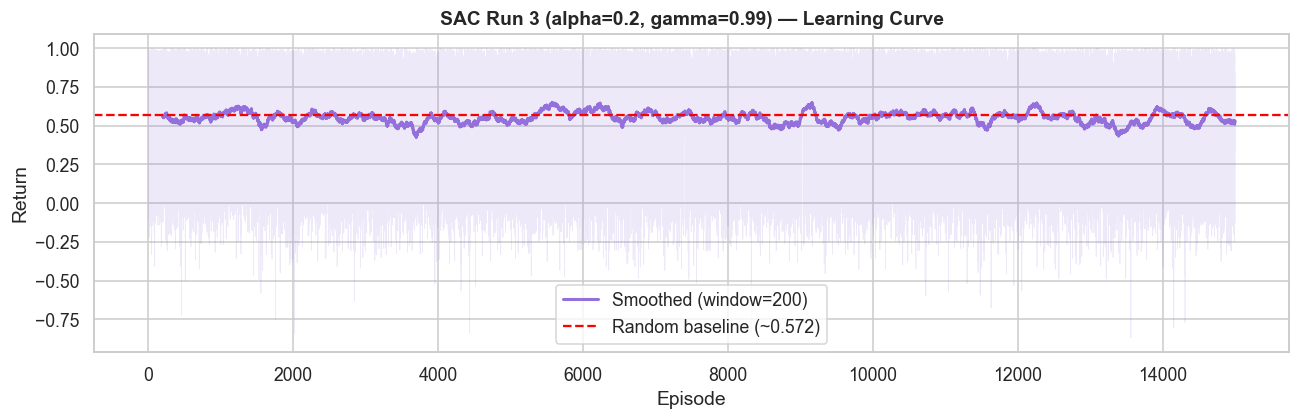

In [ ]:
# SAC Run 3 — Learning Curve
plot_learning_curve(sac_returns,
                    label    = 'SAC Run 3 (alpha=0.2, gamma=0.99)',
                    color    = 'mediumpurple',
                    filename = 'sac_run3_learning_curve.png')

it stabilizes around 3k, there's no need for 15000 episodes

In [ ]:
sac_r4 = train_sac(
    run_id     = '4_lower_alpha',
    n_episodes = 5_000,
    gamma      = 0.99,
    alpha      = 0.01,         # <-- 0.2 → 0.01 (muito mais agressivo)
    # resto igual
    buffer_size = 100_000,
    min_buffer  = 1_000,
    batch_size  = 256,
    lr_actor    = 3e-4,
    lr_critic   = 3e-4,
    tau         = 0.005,
    hidden      = 256,
    verbose     = 200,
    save_dir    = 'models/sac'
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[SAC Run 4_lower_alpha] Ep   200/5000 | return: 0.5907 | Q_mean: +0.354 | entropy: 0.788 | c_loss: 0.0134
[SAC Run 4_lower_alpha] Ep   400/5000 | return: 0.5675 | Q_mean: +0.933 | entropy: 0.418 | c_loss: 0.0122
[SAC Run 4_lower_alpha] Ep   600/5000 | return: 0.5656 | Q_mean: +1.073 | entropy: 0.296 | c_loss: 0.0219
[SAC Run 4_lower_alpha] Ep   800/5000 | return: 0.5274 | Q_mean: +1.085 | entropy: 0.238 | c_loss: 0.0256
[SAC Run 4_lower_alpha] Ep  1000/5000 | return: 0.5850 | Q_mean: +1.047 | entropy: 0.205 | c_loss: 0.0245
[SAC Run 4_lower_alpha] Ep  1200/5000 | return: 0.5689 | Q_mean: +1.055 | entropy: 0.226 | c_loss: 0.0288
[SAC Run 4_lower_alpha] Ep  1400/5000 | return: 0.5519 | Q_mean: +1.044 | entropy: 0.230 | c_loss: 0.0286
[SAC Run 4_lower_alpha] Ep  1600/5000 | return: 0.6055 | Q_mean: +1.048 | entropy: 0.230 | c_loss: 0.0328
[SAC Run 4_lower_alpha] Ep  1800/5000 | re

In [20]:
# SAC Run 4 — Evaluation (alpha=0.01, gamma=0.99) — best SAC run
sac_actor   = load_sac_actor(run_id='4_lower_alpha')
sac_returns = np.load('models/sac/sac_returns_run4_lower_alpha.npy')

sac_eval_returns, sac_eval_lengths, sac_noisy, sac_clean, sac_missing, sac_nomiss = \
    evaluate(sac_actor, make_clinical_env, is_sac=True, label='SAC Run 4')

SAC_SURVIVAL = float(np.mean(sac_eval_returns > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  SAC Run 4 — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 64.4%
  Mean return            : 0.5622
  Mean episode length    : 9.9 steps
  vs Random baseline     : +7.2pp
────────────────────────────────────────────────────
  Noisy episodes   (137): 62.8% survival
  Clean episodes   (863): 64.7% survival
  Missing feat. ep (141): 67.4% survival
════════════════════════════════════════════════════


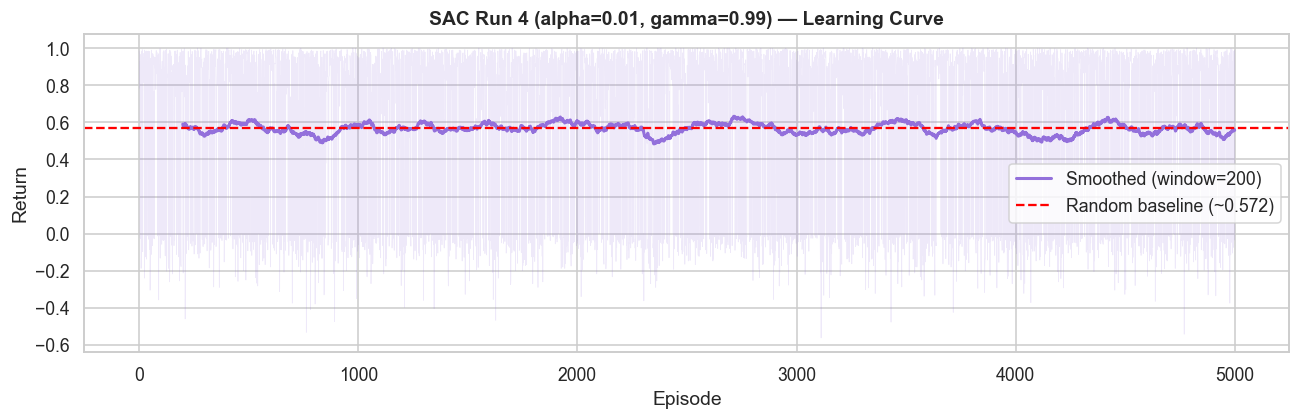

In [21]:
# SAC Run 4 — Learning Curve
plot_learning_curve(sac_returns,
                    label    = 'SAC Run 4 (alpha=0.01, gamma=0.99)',
                    color    = 'mediumpurple',
                    filename = 'sac_run4_learning_curve.png')

# <font color='#2f94d7' size=6>**7. A2C (Shared Actor-Critic Network)**</font> <a class="anchor" id="7"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**7.2 A2C — Training (Run 1)**</font> <a class="anchor" id="7_2"></a>

[Back to TOC](#toc)

In [ ]:
#  A2C — Run 1 (baseline hyperparameters)

A2C_N_UPDATES  = 150     # gradient updates
A2C_N_STEPS    = 2048    # rollout length per update
A2C_LR         = 3e-4    # learning rate
A2C_ENT_COEF   = 0.01    # entropy bonus
A2C_VF_COEF    = 0.5     # critic loss weight
A2C_MAX_GRAD   = 0.5     # gradient clipping

In [ ]:
# A2C Run 1 — Training
r1_a2c = train_a2c(
    run_id    = 1,
    n_updates = A2C_N_UPDATES,
    n_steps   = A2C_N_STEPS,
    lr        = A2C_LR,
    ent_coef  = A2C_ENT_COEF,
    vf_coef   = A2C_VF_COEF,
    max_grad  = A2C_MAX_GRAD,
)

In [ ]:
# A2C Run 1 — Evaluation
a2c_model = r1_a2c['model']

a2c_eval_returns, a2c_eval_lengths, a2c_noisy, a2c_clean, a2c_missing, a2c_nomiss = \
    evaluate(a2c_model, make_clinical_env, is_ppo=True, label='A2C')
#  NOTE: is_ppo=True because A2C uses the same Categorical policy interface as PPO

A2C_SURVIVAL = float(np.mean(a2c_eval_returns > 0)) * 100

In [ ]:
# A2C Run 1 — Learning Curve
a2c_all_returns = r1_a2c['returns']

plot_learning_curve(a2c_all_returns, label='A2C Run 1',
                    color='mediumseagreen', filename='a2c_run1_learning_curve.png')

## <font color='#2f94d7' size=6>**7.3 A2C — Analysis (Run 1) & Hyperparameter Adjustments**</font> <a class="anchor" id="7_3"></a>

[Back to TOC](#toc)

*(Fill in after running Run 1 — describe the learning curve shape,
survival rate vs. random baseline ~65.6%, and any issues observed such
as high variance or slow convergence.  Suggest adjustments for Run 2.)*

In [ ]:
#  A2C — Run 2 (Hyperparameter Tuning)
# Example adjustments — tune based on Run 1 observations:
#   - Increase n_steps for longer rollouts (lower variance estimates)
#   - Adjust ent_coef if the policy collapses too early
#   - Lower lr if training is unstable

A2C_N_UPDATES  = 200     # more updates
A2C_N_STEPS    = 4096    # longer rollouts → lower variance
A2C_LR         = 1e-4    # more conservative lr
A2C_ENT_COEF   = 0.02    # slightly higher entropy bonus
A2C_VF_COEF    = 0.5
A2C_MAX_GRAD   = 0.5

In [ ]:
# A2C — Run 2 (Hyperparameter Tuning) — Training
r2_a2c = train_a2c(
    run_id    = 2,
    n_updates = A2C_N_UPDATES,
    n_steps   = A2C_N_STEPS,
    lr        = A2C_LR,
    ent_coef  = A2C_ENT_COEF,
    vf_coef   = A2C_VF_COEF,
    max_grad  = A2C_MAX_GRAD,
)

In [ ]:
# A2C Run 2 — Evaluation
a2c_model = r2_a2c['model']

a2c_eval_returns, a2c_eval_lengths, a2c_noisy, a2c_clean, a2c_missing, a2c_nomiss = \
    evaluate(a2c_model, make_clinical_env, is_ppo=True, label='A2C')

A2C_SURVIVAL = float(np.mean(a2c_eval_returns > 0)) * 100

In [ ]:
# A2C Run 2 — Learning Curve
a2c_all_returns = r2_a2c['returns']

plot_learning_curve(a2c_all_returns, label='A2C Run 2',
                    color='mediumseagreen', filename='a2c_run2_learning_curve.png')

## <font color='#2f94d7' size=6>**7.3 A2C — Grid Search Execution**</font> <a class="anchor" id="7_3"></a>

[Back to TOC](#toc)

In [ ]:
# A2C Grid Search — Parameter Grid
# Grid design rationale (mirrors PPO grid search for fair comparison):
#
#   lr       : same range as PPO — covers conservative (1e-4) to aggressive
#              (1e-3) learning rates; A2C tends to need similar lr to PPO
#              since they share the same backbone architecture.
#
#   n_steps  : same range as PPO — controls the bias/variance tradeoff of the
#              advantage estimate; longer rollouts = lower variance but slower
#              updates. Key A2C-specific parameter (replaces PPO's n_epochs).
#
#   ent_coef : same range as PPO — governs exploration pressure; critical for
#              A2C which relies entirely on entropy for exploration (no
#              clipping mechanism to implicitly bound policy changes).
#
# Fixed params:
#   vf_coef  : 0.5  — standard weight balancing actor and critic losses
#   max_grad : 0.5  — gradient clipping, consistent with PPO setup

a2c_grid = {
    # tuned parameters (lists)
    'lr':       [1e-4, 3e-4, 1e-3],
    'n_steps':  [2048, 4096, 8192],
    'ent_coef': [0.005, 0.01, 0.02, 0.05],

    # fixed parameters
    'vf_coef':  0.5,
    'max_grad': 0.5,
}

In [ ]:
# Total: 3 × 3 × 4 = 36 configurations × 3 seeds = 108 runs
# Tip: set n_samples=12 to run a random subset if compute is limited, e.g.:
# a2c_gs_results = a2c_grid_search(a2c_grid, n_updates=100, n_samples=12)

a2c_gs_results = a2c_grid_search(
    param_grid = a2c_grid,
    seeds      = [42, 123, 7],
    n_updates  = 100,          # reduced vs. final training to save compute
)

In [ ]:
# A2C Grid Search — Results Table

print('\nTop 10 A2C configurations by survival rate:\n')
print(a2c_gs_results.head(10).to_string(index=False))

In [ ]:
# A2C Grid Search — Best Configuration

best = a2c_gs_results.iloc[0]
print('Best A2C configuration:')
print(f"  lr       = {best['lr']}")
print(f"  n_steps  = {int(best['n_steps'])}")
print(f"  ent_coef = {best['ent_coef']}")
print(f"  survival = {best['survival_mean']:.1f}% ± {best['survival_std']:.1f}%")
print(f"  return   = {best['return_mean']:.4f} ± {best['return_std']:.4f}")

# Optuna Test

In [26]:
import optuna   # adicionar ao topo do ficheiro


def evaluate_lite(model, env, n_episodes: int = 50, is_ppo: bool = False) -> float:
    """
    Avaliação rápida (greedy) usada DURANTE o treino para o Optuna decidir 
    se vale a pena continuar este trial. Devolve apenas o mean return.
    Para a avaliação final do relatório usa-se a `evaluate()` original, que 
    desagrega por noisy/clean/missing.
    """
    model.eval()
    returns = []
    with torch.no_grad():
        for _ in range(n_episodes):
            obs, _   = env.reset()
            total_r  = 0.0
            done     = False
            while not done:
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                if is_ppo:
                    logits, _ = model(obs_t)
                    action    = int(logits.argmax(1).item())
                else:
                    action = int(model(obs_t).argmax(1).item())
                obs, r, te, tr, _ = env.step(action)
                total_r += r
                done = te or tr
            returns.append(total_r)
    model.train()
    return float(np.mean(returns))


def train_dqn_pruned(
    trial:           optuna.Trial,
    n_episodes:      int   = 15_000,
    buffer_capacity: int   = 100_000,
    batch_size:      int   = 64,
    min_buffer:      int   = 500,
    lr:              float = 1e-3,
    grad_clip:       float = 10.0,
    eps_start:       float = 1.0,
    eps_end:         float = 0.05,
    eps_decay:       float = 0.9995,
    target_update:   int   = 50,
    hidden:          int   = 256,
    eval_every:      int   = 1000,
    eval_episodes:   int   = 50,
    seed:            int   = 42,
):
    """
    Versão do train_dqn usada pelo Optuna durante hyperparameter tuning.

    Diferenças vs train_dqn:
      - Aceita um trial do Optuna e reporta-lhe a performance a cada `eval_every`
        episódios, permitindo terminar trials maus mais cedo (pruning).
      - Avalia num ambiente separado com política greedy (argmax), o que dá
        uma curva muito mais limpa que a curva de treino com epsilon-greedy.
      - Não guarda pesos em disco (não vale a pena para 20 trials).
      - Aceita `hidden` como hiperparâmetro tunable (o QNetwork tem de 
        aceitar este parâmetro, já aceita).
    """

    # Reprodutibilidade
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)

    # Redes
    online = QNetwork(hidden=hidden).to(device)
    target = QNetwork(hidden=hidden).to(device)
    target.load_state_dict(online.state_dict())
    target.eval()

    optimiser = torch.optim.Adam(online.parameters(), lr=lr)
    buffer    = ReplayBuffer(buffer_capacity)

    env      = make_clinical_env()
    env_eval = make_clinical_env()

    all_returns  = []
    eval_history = []      # [(episode, mean_eval_return), ...]
    eps          = eps_start

    for ep in range(n_episodes):
        obs, _    = env.reset(seed=int(rng.integers(1_000_000)))
        ep_return = 0.0
        done      = False

        while not done:
            if random.random() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    obs_t  = torch.FloatTensor(obs).unsqueeze(0).to(device)
                    action = int(online(obs_t).argmax(1).item())

            next_obs, reward, te, tr, _ = env.step(action)
            done = te or tr
            buffer.push(obs, action, reward, next_obs, float(done))
            obs        = next_obs
            ep_return += reward

            if len(buffer) >= min_buffer:
                states, actions, rewards, next_states, dones = buffer.sample(batch_size)

                states_t      = torch.FloatTensor(states).to(device)
                actions_t     = torch.LongTensor(actions).to(device)
                rewards_t     = torch.FloatTensor(rewards).to(device)
                next_states_t = torch.FloatTensor(next_states).to(device)
                dones_t       = torch.FloatTensor(dones).to(device)

                q_values = online(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)

                with torch.no_grad():
                    next_q   = target(next_states_t).max(1)[0]
                    q_target = rewards_t + GAMMA * next_q * (1 - dones_t)

                loss = F.mse_loss(q_values, q_target)
                optimiser.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(online.parameters(), grad_clip)
                optimiser.step()

        all_returns.append(ep_return)
        eps = max(eps_end, eps * eps_decay)

        if ep % target_update == 0:
            target.load_state_dict(online.state_dict())

        # Avaliação periódica + report ao Optuna
        if (ep + 1) % eval_every == 0:
            mean_eval = evaluate_lite(online, env_eval, n_episodes=eval_episodes)
            eval_history.append((ep + 1, mean_eval))

            trial.report(mean_eval, step=ep + 1)
            if trial.should_prune():
                env.close()
                env_eval.close()
                raise optuna.TrialPruned()

    env.close()
    env_eval.close()

    return {
        'online':       online,
        'returns':      all_returns,
        'eval_history': eval_history,
    }

In [28]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner


def objective_dqn(trial: optuna.Trial) -> float:
    # Search space
    lr            = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    eps_decay     = trial.suggest_float('eps_decay', 0.995, 0.9999)
    target_update = trial.suggest_categorical('target_update', [25, 50, 100, 200])
    hidden        = trial.suggest_categorical('hidden', [128, 256, 512])
    buffer_cap    = trial.suggest_categorical('buffer_capacity', [50_000, 100_000, 200_000])

    # Train com pruning ativado
    result = train_dqn_pruned(
        trial           = trial,
        n_episodes      = 15_000,
        lr              = lr,
        batch_size      = batch_size,
        eps_decay       = eps_decay,
        target_update   = target_update,
        hidden          = hidden,
        buffer_capacity = buffer_cap,
        eval_every      = 1000,
        eval_episodes   = 50,
        seed            = 42,
    )

    # Métrica a otimizar: média das últimas 3 avaliações (mais robusto que a última só)
    last_evals = [eval_return for _, eval_return in result['eval_history'][-3:]]
    return float(np.mean(last_evals))


study = optuna.create_study(
    direction      = 'maximize',
    sampler        = TPESampler(seed=SEED),
    pruner         = MedianPruner(
        n_startup_trials = 5,        # primeiros 5 trials correm até ao fim
        n_warmup_steps   = 3_000,    # nunca prunar antes do episódio 3000
    ),
    study_name     = 'dqn_config_b',
    storage        = 'sqlite:///models/optuna_dqn.db',
    load_if_exists = True,
)

study.optimize(objective_dqn, n_trials=20, show_progress_bar=True)

print(f'\nBest value : {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

[I 2026-05-27 12:53:03,456] A new study created in RDB with name: dqn_config_b


  0%|          | 0/20 [00:00<?, ?it/s]

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[I 2026-05-27 12:59:27,400] Trial 0 finished with value: 0.5700166666666667 and parameters: {'lr': 0.0001329291894316216, 'batch_size': 32, 'eps_decay': 0.9957643731496474, 'target_update': 50, 'hidden': 256, 'buffer_capacity': 50000}. Best is trial 0 with value: 0.5700166666666667.
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[I 2026-05-27 13:17:22,096] Trial 1 finished with value: 0.5716666666666667 and parameters: {'lr': 8.17949947521167e-05, 'batch_size': 256, 'eps_decay': 0.995683519917195, 'target_update': 200, 'hidden': 512, 'buffer_capacity': 100000}. Best is trial 1 with value: 0.571666666

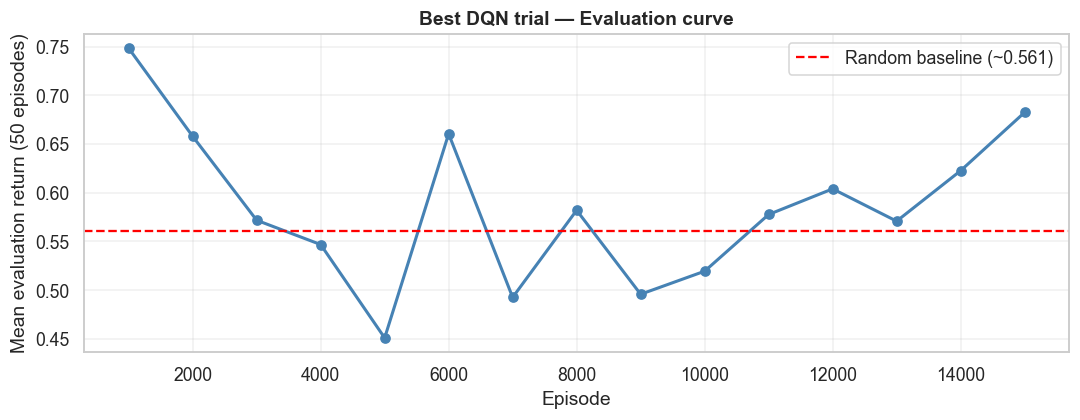

In [29]:
# Best trial: extrair a learning curve
best_trial = study.best_trial
intermediate = best_trial.intermediate_values   # dict {step: value}

episodes    = sorted(intermediate.keys())
eval_returns = [intermediate[ep] for ep in episodes]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(episodes, eval_returns, marker='o', color='steelblue', linewidth=2)
ax.axhline(clinical_rand_mean, color='red', linestyle='--', linewidth=1.5,
           label=f'Random baseline (~{clinical_rand_mean:.3f})')
ax.set_xlabel('Episode')
ax.set_ylabel('Mean evaluation return (50 episodes)')
ax.set_title(f'Best DQN trial — Evaluation curve', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
def plot_eval_curve(eval_history, label, color, baseline=None):
    """Plot da curva de avaliação (uma média de N eval episodes a cada X training episodes)."""
    episodes     = [ep for ep, _ in eval_history]
    eval_returns = [r  for _, r  in eval_history]
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(episodes, eval_returns, marker='o', color=color, linewidth=2, 
            markersize=6, label=f'{label} eval return')
    
    if baseline is not None:
        ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5,
                   label=f'Random baseline (~{baseline:.3f})')
    
    ax.set_xlabel('Training episode')
    ax.set_ylabel('Mean evaluation return (greedy, 50 episodes)')
    ax.set_title(f'{label} — Evaluation Curve', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()